# Naive Bayes i Classificació


#### Autors: David Díez i Mario Vilar

En aquest tercer lliurament es programarà un classificador, que donada una *piulada*, la categoritzarà en una de les possibles classes. En aquesta ocasió, implementareu un classificador amb *piulades* relacionades amb el *cyber bullying*.

Recordeu que l'objectiu principal d'aquesta pràctica és desenvolupar un classificador amb una *accuracy* alta. 


**Què s’ha de fer?**

Volem classificar *piulades* segons a quin tipus de *cyber bullying* pertanyen. Així doncs, a partir de tots les *piulades* que tenim, crearem un vector de característiques que ens descrigui cadascuna. A continuació desenvoluparem un classificador probabilístic del tipus **Naive Bayes** que ens permeti identificar a quina classe de *cyber bullying* pertany una *piulada* donada, segons les característiques disenyades.


**Quina és la idea del sistema de classificació que s’ha de desenvolupar?**

El classificador és un concepte de l'aprenentatge automàtic supervisat. L'objectiu del classificador és donat un vector de característiques que descriuen els objectes que es volen classificar indicar a quina categoria o classe pertanyen d'entre un conjunt predeterminat. 

El procés de classificació consta de dues parts: 

+ el procés d'aprenentatge i 
+ el procés d'explotació o testeig. 

El procés d'aprenentatge rep exemples de parelles $(x,y)$ on $x$ són les característiques, usualment representades per nombres reals, i $y$ és la categoria a la que pertanyen. 
Aquest conjunt se'l coneix com a conjunt d'entrenament i ens servirà per trobar una funció $\hat{y}=f(x)$ que donada una $x$ aconsegueixi que $\hat{y}$ sigui semblant $y$. 

Per altra banda el procés de testeig aplica la funció $f(x)$ apresa a l'entrenament a a dades no presents en el conjunt d'aprenentatge per avaluar el classificador.

**Classificació i llenguatge natural**

La descripció dels exemples en característiques és el punt més crític de tot sistema d'aprenentatge automàtic. 
Una de les representacions més simples per tal de descriure un text és la representació ["bag-of-words"](https://en.wikipedia.org/wiki/Bag-of-words_model).

Aquesta representació converteix un text en un vector de $N$ paraules. 
Primer haurem de seleccionar el conjunt d'$N$ paraules que volem fer servir. Després, per cada paraula comptar quants cops apareix en el text. 

Una versió alternativa i més simple d'aquest procés pot ser simplement indicar al vector si una determinada paraula apareix o no en el text.

## Abans de començar


**\+ Durant la pràctica, solament es podran fer servir les següents llibreries**:

`Pandas, Numpy, Re` i `NLTK`

Python té un paquet integrat anomenat ["re"](https://www.w3schools.com/python/python_regex.asp), que es pot utilitzar per treballar amb expressions regulars. És molt aconsellable fer servir aquest paquet per processar les paraules.

**\+ No es poden modificar les definicions de les funcions donades, ni canviar els noms de les variables i paràmetres ja donats**

Això no implica però que els hàgiu de fer servir. És a dir, que la funció tingui un paràmetre anomenat `df` no implica que l'hàgiu de fer servir, si no ho trobeu convenient.

**\+ En les funcions, s'especifica que serà i de quin tipus cada un dels paràmetres, cal respectar-ho**

Per exemple (ho posarà en el pydoc de la funció), `df` sempre serà indicatiu del `Pandas.DataFrame` de les dades. Durant els testos, els paràmetres (i específicament `df`) no contindran les mateixes dades que en aquest notebook, si bé si seran del mateix tipus! Per tant, no us refieu de què tinguin, per exemple, el mateix nombre de files.

## Aprenent Regex

#### [] --> A set of characters
Ejemplo: Busca cualquier letra de la a a la m.

pattern = "[a-m]"

print(re.findall(pattern, "abcdefgijklmnopqrstuvwxyz"))  # ['a', 'b', 'c', ..., 'm']

#### \ --> Signals a special sequence or escapes a special character
Ejemplo: Busca cualquier número.

pattern = "\d"

print(re.findall(pattern, "abc123"))  # ['1', '2', '3']

#### . --> Any character (except newline)
Ejemplo: Busca cualquier carácter excepto nueva línea.

pattern = "c.t"

print(re.findall(pattern, "cat cot cut cxt"))  # ['cat', 'cot', 'cut', 'cxt']

#### ^ --> Starts with
Ejemplo: Verifica si una cadena comienza con "Hello".

pattern = "^Hello"

print(re.search(pattern, "Hello World!"))  # Match object o None

#### $ --> Ends with
Ejemplo: Verifica si una cadena termina con "World".

pattern = "World!$"

print(re.search(pattern, "Hello World!"))  # Match object o None

#### * --> Zero or more occurrences
Ejemplo: Busca cero o más "a".

pattern = "a*"

print(re.findall(pattern, "aaaaab"))  # ['aaaaa', '', '', '', '']

#### + --> One or more occurrences
Ejemplo: Busca una o más "a".

pattern = "a+"

print(re.findall(pattern, "aaaaab"))  # ['aaaaa']

#### {} --> Exactly the specified number of occurrences
Ejemplo: Busca exactamente dos "l".

pattern = "l{2}"

print(re.findall(pattern, "Hello"))  # ['ll']

#### | --> Either or
Ejemplo: Busca "cat" o "dog".

pattern = "cat|dog"

print(re.findall(pattern, "cat and dog"))  # ['cat', 'dog']

#### () --> Capture and group
Ejemplo: Busca "a" seguida de cualquier carácter y luego "c".

pattern = "(a.c)"

print(re.findall(pattern, "abc adc"))  # ['abc', 'adc']

#### \A --> Returns a match if the specified characters are at the start of the string
Ejemplo: Verifica si comienza con "The".

pattern = "\AThe"

print(re.search(pattern, "The quick brown fox"))  # Match object o None

#### \b --> Matches where the specified characters are at the beginning or end of a word
Ejemplo: Busca "ain" al inicio o final de una palabra.

pattern = r"\bain"

print(re.findall(pattern, "ain is in the rain"))  # ['ain']

#### \B --> Matches where the specified characters are NOT at the beginning or end of a word
Ejemplo: Busca "ain" no al inicio o final de una palabra.

pattern = r"\Bain"

print(re.findall(pattern, "The rain in Spain"))  # ['ain']

#### \d --> Matches digits (0-9)
Ejemplo: Busca cualquier número.

pattern = "\d"

print(re.findall(pattern, "I have 2 apples and 5 oranges"))  # ['2', '5']

#### \D --> Matches non-digits
Ejemplo: Busca caracteres que no sean números.

pattern = "\D"

print(re.findall(pattern, "I have 2 apples."))  # ['I', ' ', 'h', ..., 's', '.']

#### \s --> Matches whitespace character
Ejemplo: Busca espacios en blanco.

pattern = "\s"

print(re.findall(pattern, "Hello World"))  # [' ']

#### \S --> Matches non-whitespace character
Ejemplo: Busca caracteres que no sean espacios en blanco.

pattern = "\S"

print(re.findall(pattern, "Hello World"))  # ['H', 'e', 'l', ..., 'd']

#### \w --> Matches alphanumeric characters (a-z, A-Z, 0-9, _)
Ejemplo: Busca caracteres alfanuméricos.

pattern = "\w"

print(re.findall(pattern, "Python 3.9"))  # ['P', 'y', 't', ..., '3', '9']

#### \W --> Matches non-alphanumeric characters
Ejemplo: Busca caracteres que no sean alfanuméricos.

pattern = "\W"

print(re.findall(pattern, "Python 3.9"))  # [' ', '.']

#### \Z --> Returns a match if the specified characters are at the end of the string
Ejemplo: Verifica si termina con "fox".

pattern = "fox\Z"

print(re.search(pattern, "The quick brown fox"))  # Match object o None

#### [abc] --> Matches any of the characters inside the brackets
Ejemplo: Busca 'a', 'b' o 'c'.

pattern = "[abc]"

print(re.findall(pattern, "abcdef"))  # ['a', 'b', 'c']

#### [a-z] --> Matches any character in the range
Ejemplo: Busca letras minúsculas de la 'a' a la 'z'.

pattern = "[a-z]"

print(re.findall(pattern, "Hello123"))  # ['e', 'l', 'l', 'o']

#### [^abc] --> Matches any character NOT in the set
Ejemplo: Excluye 'a', 'b' y 'c'.

pattern = "[^abc]"

print(re.findall(pattern, "abcdef"))  # ['d', 'e', 'f']

#### [0-9] --> Matches any digit (cualquier dígito)
Ejemplo: Busca números del 0 al 9.

pattern = "[0-9]"

print(re.findall(pattern, "House number 42"))  # ['4', '2']

#### [0-5][0-9] --> Matches ranges for multiple positions
Ejemplo: Busca números del 00 al 59.

pattern = "[0-5][0-9]"

print(re.findall(pattern, "Time: 14:59, 23:45"))  # ['14', '59', '23', '45']

#### [a-zA-Z] --> Matches both uppercase and lowercase characters
Ejemplo: Busca letras en ambos casos.

pattern = "[a-zA-Z]"

print(re.findall(pattern, "Python 3.10"))  # ['P', 'y', 't', 'h', 'o', 'n']

#### [+] --> Matches the '+' character specifically
Ejemplo: Busca el símbolo '+'.

pattern = "[+]"

print(re.findall(pattern, "3+2=5"))  # ['+']

#### [^0-9] --> Matches any non-digit
Ejemplo: Busca caracteres no numéricos.

pattern = "[^0-9]"

print(re.findall(pattern, "Room 404"))  # ['R', 'o', 'o', 'm', ' ']

## Les dades

El 15 d'Abril de 2020, UNICEF va llançar una alarma com a resposta de l'augment de risc de *cyber bullying* durant la pandèmia COVID-19. 

Les estadístiques són prou alarmants: un 36.5% dels estudiants de l'escola fins a l'institut s'han sentit víctimes del *cyber bullying* i un 87% n'han estat testimonis, amb efectes que van des d'una disminució de resultats acadèmics fins a pensaments suïcides.

Amb l'objectiu d'ajudar a l'analisis de la situació, s'ha construit un dataset que conté més de 47000 *piulades* etiquetades d'acord amb la classe de *cyber bullying* que s'està donant:

1. `age`;
2. `ethnicity`;
3. `gender`;
4. `religion`;
5. `other type of cyberbullying`;
6. `not cyberbullying`

Les dades han estat balancejades per tal de contenir aproximadament 8000 mostres de cada classe.

# Preparar les dades

## Lectura de les dades

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

In [2]:
df = pd.read_csv('data/cyberbullying_tweets.csv')
df

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


In [3]:
df['cyberbullying_type'].value_counts()

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

## Preparació del dataset

Dividim les *piulades* en un conjunt d'entrenament, *train*, i en un conjunt de validació, *test*, per tal de poder entrenar i validar el nostre model de classificació.

In [4]:
from sklearn.model_selection import train_test_split

df_tweets_train, df_tweets_test = train_test_split(df, test_size=0.2)

Com les dades estaven balancejades originalment, podem observar que la distribució de cadascuna de les classes es manté:

In [5]:
df_tweets_train['cyberbullying_type'].value_counts()

cyberbullying_type
age                    6429
religion               6427
gender                 6403
not_cyberbullying      6379
ethnicity              6304
other_cyberbullying    6211
Name: count, dtype: int64

In [6]:
df_tweets_test['cyberbullying_type'].value_counts()

cyberbullying_type
ethnicity              1657
other_cyberbullying    1612
religion               1571
gender                 1570
not_cyberbullying      1566
age                    1563
Name: count, dtype: int64

# Implementació

Dividirem el notebook en 3 seccions que es complementen una a l'altra:

1. Anàlisi exploratòria de les dades: Informació bàsica sobre les *piulades*.
2. Processament de les dades: Creació d'un vector de característiques a partir de les *piulades*.
3. Desenvolupament d'un classificador *Naive Bayes*. 

### 1. Anàlisis de dades

El primer que haurem de fer és analitzar les dades per veure una mica com són. El que us proposem és fer una sèrie de visualitzacions per observar les dades, com ara:

* el nombre de *piulades* que s'estan dirigint a una persona en concret
* el nombre de  *hashtags* que hi ha a cada categoria de *piulades*
* el nombre de  *piulades* que hi ha de cada categoria de *piulades*
* el nombre de  *piulades* de la categoria `not_cyberbullying` que es dirigeixen a un usuari vs totes les altres categories
* altres coses que penseu que poden ser rellevants.

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
df_tweets_train.head()

,tweet_text,cyberbullying_type
40865,@HeyIts_Jayla @ryan_temple goodone dumb nigger...,ethnicity
33136,I bullied them in high school and I’ll bully t...,age
22287,"My mother, when pokemon first came out: oh HEL...",religion
2566,If 2 #mkr contestants were to be ousted by Kat...,not_cyberbullying
14340,RT @DanielSheppard5: I felt so out of place at...,gender


#### EXTRA:

Abans de començar crearem una serie de funcions auxiliars per mostrar diferents tipus de gràfics i poder entendre millor les dades

In [75]:
# No modificar aquesta cel·la, s'encarrega de fer el procés més eficient.
# Intenteu entendre quà fa aquesta cel·la
def memo(f):
    class memodict(dict):
        def __init__(self, f):
            self.f = f
        def __call__(self, *args):
            return self[args]
        def __missing__(self, key):
            ret = self[key] = self.f(*key)
            return ret
    return memodict(f)

@memo    
def standardize(word):
    """
    :param word: paraula a estandaritzar
    :return : paraula estandaritzada
    """
    # Convertim a minúscules
    word = word.lower()
    
    # Eliminem els simbols no permesos
    word = re.sub(r"[^a-z0-9@#_ ]", "", word)

    # Eliminem espais innecessaris
    word = re.sub(r"\s+", " ", word).strip()
    
    # Remove URLs
    word = re.sub(r'^https?:\/\/.[\r\n]', '', word)
    
    # Remove punctuation and others
    word = re.sub(r'[^a-z\s]', '', word)
    
    # Remove repeated characters
    re.sub(r'(.)\1{3,}', r'\1', word)
    # Remove extra spaces
    word = re.sub(r'\s+', ' ', word).strip()
    
    return word

# Creem aquesta funció auxiliar per cridar standardize
def standarize_text(word):
    """
    :param word: paraula a estandaritzar
    :return : paraula estandaritzada utilitzant standardize
    """
    return standardize(word)

def count_words(df):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {word : {n_ocur: valor, n_tweets: valor}, ...}
    """
    # Utilizem apply amb la funció standarize_text() que acabem de definir
    standarizedText =  df["tweet_text"].apply(standarize_text)
    
    # IDEA: Crear un df amb totes les paraules i fer un value_counts()
    # Després tornarem al df original y comptarem els tweets on surt cada paraula
    
    # Combinem tots els tweets en un únic text i dividim en paraules
    all_words = " ".join(standarizedText).split(" ")

    # Comptar totes les ocurrències de paraules (n_ocur)
    word_count = pd.Series(all_words).value_counts()

    # Comptar en quants tweets apareix cada paraula (n_piu)
    # Convertim cada tweet en un conjunt de paraules úniques
    unique_words_per_tweet = standarizedText.apply(lambda x: set(x.split()))
    tweet_count = pd.Series([word for tweet in unique_words_per_tweet for word in tweet]).value_counts()
    
    # Construim el diccionari directament
    dicc = {
        word: {"n_ocur": word_count[word], "n_piu": tweet_count[word]}
        for word in word_count.index if word.strip()
    }

    return dicc

def count_words_categories(df):
    """
    Funció que ha de constuir un diccionari que conté la freqüència de les 
    paraules i el número de piulades on ha aparegut. 
    Aquesta informació ha de ser dividida per diferents categories de cyberbullying.
    
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {label : {word : {n_ocur: valor, n_news: valor} } }
    """
    words_topic = {}

    def eachTopic(group):
        # Count words on this topic and save to dictionary
        words_topic[group['cyberbullying_type'].iloc[0]] = count_words(group)
        
    # IDEA: Agafar tots els tipus de cyberbullying
    # i cridar la funció eachTopic per cadascun d'ells
    categories = df["cyberbullying_type"].unique()

    for category in categories:
        data = df[df["cyberbullying_type"] == category]
        eachTopic(data)
    
    return words_topic

def topNwords(df, words, N, skip=[]):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :param words: diccionari amb les paraules i la seva frequencia
    :param N: número de paraules més representatives que volem considerar
    :return : Diccionari amb el format {categoria1: llista_top_words_cat_1,  
                                        categoria2: llista_top_words_cat_2, ...} 
    """
    top_words=dict()
    
    # IDEA: Iterar pel diccionari amb les paraules
    # i les ocurrencies i buscar les N més representatives
    
    # Guardem les categories de cyberbullying
    categories = df["cyberbullying_type"].unique()

    for category in categories:
        # Guardem la informació de cada categoria
        category_words = words[category]
                
        # Per totes les paraules de la categoria mirem si és vàlida
        filtered_words = {word: freq for word, freq in category_words.items() if word not in skip}

        # Ordenem les paraules per n_ocur de forma descendent
        sorted_words = sorted(filtered_words.items(), key=lambda x: x[1]["n_ocur"], reverse=True)

        # Seleccionem les N paraules més representatives
        top_category_words = [word for word, _ in sorted_words[:N]]

        # Afegim la llista al diccionari
        top_words[category] = top_category_words
    
    return top_words

def create_features(df, top_words): 
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params top_words: ha de ser el diccionari que retorna topNWords
    :return : diccionari o pd.Series que conté un np.array per a 
        cadascuna de les piulades amb el vector de característiques corresponent.
    """

    # IDEA: Guardar totes les paraules úniques escrites i per cada
    # comentari veure si aquesta paraula surt o no.
    # Per fer això utilitzarem moltes llistes, 
    # set i list/set-comprehension. És fundamental (i de fet vam tenir problemes)
    # que es controlin bé els indexos perque es fan moltes iteracions
    # i és fàcil liar-la
    
    # Combinar totes les paraules top de totes les categories
    unique_words = list(set(word for words in top_words.values() for word in words))

    # Crear un índex per accedir ràpidament a les paraules
    word_index = {word: idx for idx, word in enumerate(unique_words)}
    
    # Inicialitzar el diccionari de vectors de característiques
    dict_feat_vector = {}

    # Utilizem apply amb standarize_text
    standarizedText =  df["tweet_text"].apply(standarize_text)

    # Agafem l'index i el tweet
    # És important agafar aquest index, sinó perdem 
    # consistencia amb la resta de la taula
    for idx, tweet in standarizedText.items():
        # Dividim el tweet en paraules
        tweet_words = set(tweet.split())
        
        # Inicialitzem el vector de característiques
        feature_vector = np.zeros(len(unique_words), dtype=int)
        
        # Marquem les paraules que hi ha al tweet
        for word in tweet_words:
            if word in word_index:
                feature_vector[word_index[word]] = 1
        
        # Assignem el vector
        dict_feat_vector[idx] = feature_vector
    
    return dict_feat_vector

def naive_bayes_learn(df, feats):
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params feats: vector de característiques de cada piulada
    :return : probabilitats marginals condicionades
    """
    # IDEA: Implementar la formula detallada adalt i trobar
    # A, B i M. Això ho farem jugant amb les categories
    # i amb el vector de característiques
    
    # Guardem les categories i la quantitat que hi ha
    categories = df["cyberbullying_type"].unique()

    # M és el total de categories
    M = len(categories)

    # Inicialitzem la estructura per guardar les probabilitats de cada categoria
    probs = {category: [] for category in categories}

    # Iterem per totes les categories per calcular les probabilitats
    for category in categories:
        # Agafem les piulades d'aquesta categoria i les guardem com una matriu
        category_indices = df[df["cyberbullying_type"] == category].index
        category_feats = np.array([feats[i] for i in category_indices])
        
        # A és total de piulades on surt una paraula en particular
        # Podem fer la suma per columnes perque cada fila és una piulada 
        # amb 0 o 1 a la posició i-ésima en cas de tener la paraula o no
        # per tant, fer la suma per columnes equival a comptar quantes piulades
        # tenen una paraula en particular
        A = np.sum(category_feats, axis=0)

        # B és el total de piulades hi ha a aquesta categoria
        B = len(category_feats)

        # Apliquem la correcció de Laplace
        probs[category] = (A + 1) / (B + M)

    return probs
    
import sys
from IPython import embed
def naive_bayes(df_train, feat_train, feat_test=None, df_test=None):
    """
    Funció que implementa el clasificador Naive_Bayes.
    
    Si df_test no és None, ha de calcular l'encert sobre les dades de test. És a dir,
    després de classificar feat_test ha de comparar la classificació amb la classe
    real i dir (print) quin percentatge d'encert ha obtingut.
    
    :param df_train: DataFrame amb les piulades que s'utilitzaran per l'entrenament
    :param feat_train: Diccionari amb els vectors de caracteristiques de cada tweet de l'entrenament
    :param feat_test: Diccionari amb els vectors de caracteristiques de cada tweet de test
    :param df_test: DataFrame amb les piulades que s'utilitzaran pel test
    
    :return : Una serie on l'index correspon amb els indexos de df_test i els valors són la
              classificació retornada per Naive Bayes
    """
    probs = naive_bayes_learn(df_train, feat_train)
    p_of_cat = count_words_categories(df_train)
    p_total = len(p_of_cat.keys())
    
    def eachFeats(row):
        id, feat = row
        p_max = float('-inf')
        p_cat = 0

        # IDEA: Agrupar tota la informació i aplicar les formules
        # observem a la demostració de l'us dels logaritmes
        # que s'ha detallat a la part superior        
        
        for category in probs:
            # Speed up by using numpy
            # inv is the inverse of features, 0 where 1 and 1 where 0
            inv_feat = 1 - feat
            
            # Probs * feats is the probability of being there, while
            # inv - inv * feat = 1 - (0, 1, 0... inverses) * probs, probability of not being there
            prob_there = probs[category]
            prob_not_there = 1 - probs[category]
            
            # Sum of logs [vs] underflow caused by mul of probs
            log_sum = np.sum(feat * np.log(prob_there) + inv_feat * np.log(prob_not_there))

            # Take the max, do it now to avoid extra-loops
            if log_sum > p_max:
                p_max = log_sum
                p_cat = category
        return id, p_cat
    
    data = map(eachFeats, feat_test.items())
    data = pd.Series(dict(data))
    correct = data == df_test['cyberbullying_type']
    print("Accuracy: {}".format(correct.sum() / correct.size))
    
    return correct.sum() / correct.size

def acc(train, test, N=10, skip=[]):
    """
    Retorna l'accuracy donades certes condicions
    
    :param train: DataFrame per entrenar el model
    :param test: DataFrame per testejar el model
    :param N: número de paraules més representatives que volem considerar 
    :param skip: llista de stopwords
    :return : Escalar (float) corresponent a l'accuracy
    """  
    
    words_topics = count_words_categories(train)
    top_words = topNwords(train, words_topics, N, skip)

    feat_train = create_features(train, top_words)
    feat_test = create_features(test, top_words)
    accuracy = naive_bayes(train, feat_train, feat_test, test)
    return accuracy

N = 40 # Aquest parametre el podeu canviar i fer proves per avaluar quin és el millor valor. 
skip_top=[]
accuracy = acc(df_tweets_train, df_tweets_test, N=N, skip=skip_top)

Accuracy: 0.7347730370059755


In [11]:
def compare2values(df, df2compare, categories, title, ylabel):
    """
    Funció que mostra la diferencia entre una categoria i la resta
    
    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - df2compare (DataFrame): El DataFrame amb el que volem fer la comparació 
    - categories (list): Cateogories que estudiem
    - title (str): Títol de la taula.
    - ylabel (str): Nom de l'eix vertcial.
    """
    
    # Nombre de piulades dirigides a un usuari
    total_values = df.shape[0]
    interested_values = df2compare.shape[0]
    other_values = total_values - interested_values
    
    # Dades per al gràfic
    valors = [interested_values, other_values, total_values]
    
    # Crear el gràfic de barres
    plt.figure(figsize=(16, 6))
    bars = plt.bar(categories, valors, color=['blue', 'orange', 'red'])
    
    # Afegir etiquetes a sobre de cada barra
    for bar in bars:
        height = bar.get_height()  # Obtenir l'alçada de la barra
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5,  # Coordenades del text
                 str(height),  # Valor a mostrar
                 ha='center', va='bottom', fontsize=10)  # Alineació i estil
    plt.title(title)
    plt.ylabel(ylabel)
    plt.show()

In [12]:
def visualize_bars(df, column, title, xlabel, ylabel):
    """
    Funció que crea una figura de barres a partir del dataframe i
    la columna que conté la informació

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (str): Columna que volem filtrar.
    - title (str): Títol de la taula.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    """

    # Comptem els viatges
    data = df[column].value_counts().sort_index()
    # Alternativament, si volguéssim podríem fer servir
    # data = df.groupby(column).size()

    # Creem el gràfic
    plt.figure(figsize=(15,6))

    # Fem les barres
    bars = plt.bar(data.index, data.values, color='skyblue', alpha=0.7)

    # Afegir etiquetes a sobre de cada barra
    for bar in bars:
        height = bar.get_height()  # Obtenir l'alçada de la barra
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5,  # Coordenades del text
                 str(height),  # Valor a mostrar
                 ha='center', va='bottom', fontsize=10)  # Alineació i estil
    
    # Anomenem els eixos segons els valors passats per paràmetre
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Mostrem els valors a l'eix x
    plt.xticks(data.index)

    plt.show()

In [13]:
def visualize_histograms(df, column, title, xlabel, ylabel):
    """
    Funció que crea un histograma a partir de la informació que conté la columna del dataframe

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (str): Columna que volem estudiar.
    - title (str): Títol de la taula.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    """

    # Obtenemos los valores únicos si son categorías
    data = df[column].value_counts().sort_index()

    # Creem el gràfic
    plt.figure(figsize=(15,6))

    # Fem l'histograma
    bars = plt.hist(df[column], histtype='bar', alpha=0.5, bins=len(data), align='mid')
        
    # Anomenem els eixos segons els valors passats per paràmetre
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Mostrem els valors a l'eix x
    plt.xticks(data.index)

    plt.show()

In [14]:
def visualize_lines(df, column, title, xlabel, ylabel):
    """
    Funció que visualitza els viatges per diferents agregacions de dades

    Parameters:
    - df (DataFrame): El DataFrame amb el que treballem.
    - column (list): Columnes que comparem.
    - title (str): Títol de la taula.
    - xlabel (str): Nom de l'eix horitzonal.
    - ylabel (str): Nom de l'eix vertcial.
    """

    # Comptem els viatges
    data = df[column].value_counts().sort_index()
    # Alternativament, si volguéssim podríem fer servir
    # data = df.groupby(column).size()

    # Creem el gràfic
    plt.figure(figsize=(15,6))

    # Fem el dibuix
    bars = plt.plot(data.index, data.values, linestyle='--', marker='o', label=column)

    # Afegim text per mostrar el valor de cada punt
    for x, y in zip(data.index, data.values):
        plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=10)
        
    # Anomenem els eixos segons els valors passats per paràmetre
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Mostrem els valors a l'eix x
    plt.xticks(data.index)

    plt.show()

#### EXERCICI 1: 

* Quantes *piulades* estan dirigides a un usuari concret? Diem que una piulada va dirigida a una persona en concret si contenen el patró ``@usuari``. 

[Restriccions](https://help.twitter.com/en/managing-your-account/change-twitter-handle) que imposa X sobre el patró:
+ Nomes són valids aquells patrons amb caràcters alfanumèrics ``[A-z 0-9]`` i el caràcter ``_``
+ Els patrons han de començar per ``@`` i han de tenir més de 4 i menys de 16 caràcters.

En aquest exercici és extremadament útil l'ús del mòdul ``re``.

In [15]:
# Patró del nom d'usuari
patro_nom_usuari = r"@[A-Za-z0-9_]{5,15}"

# Obtenim el recompte
piulades_usuari = df[df["tweet_text"].str.contains(patro_nom_usuari, regex=True)]
piulades_usuari.shape[0]

17901

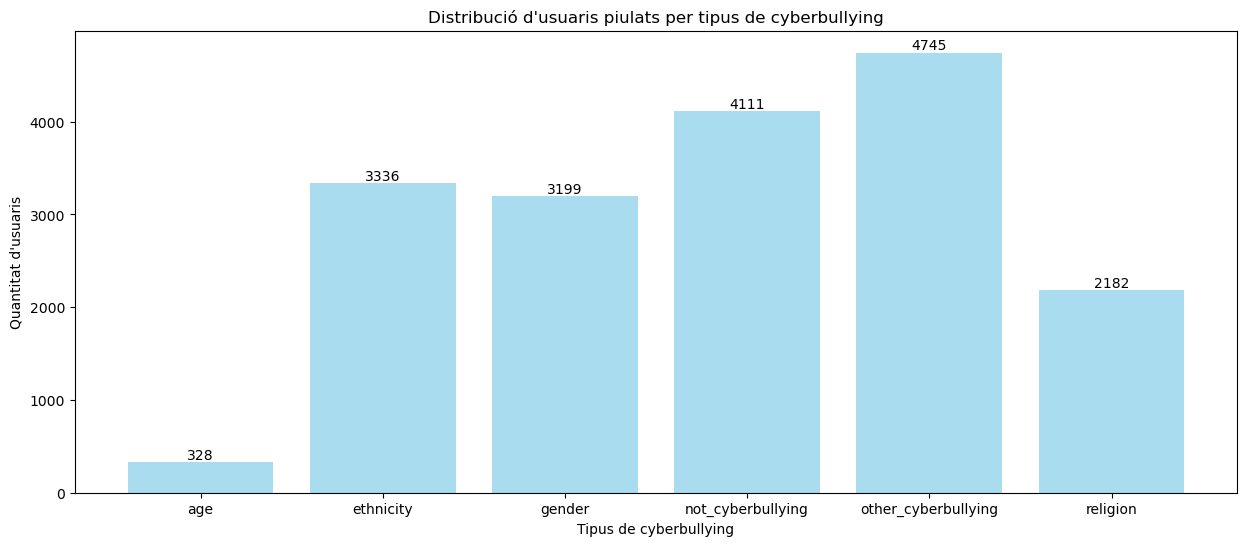

In [16]:
visualize_bars(piulades_usuari,
               "cyberbullying_type",
               "Distribució d'usuaris piulats per tipus de cyberbullying",
               "Tipus de cyberbullying",
               "Quantitat d'usuaris")

Amb aquest gràfic de barres podem vuere quants usuaris son piulats per cada categoria. Observem que la gent no acostuma a ficar-se amb els altres per temes de l'edat però si que ho fan pel gènere o la etnia.

Destaca que **not_cyberbullying** té un valor molt elevat.

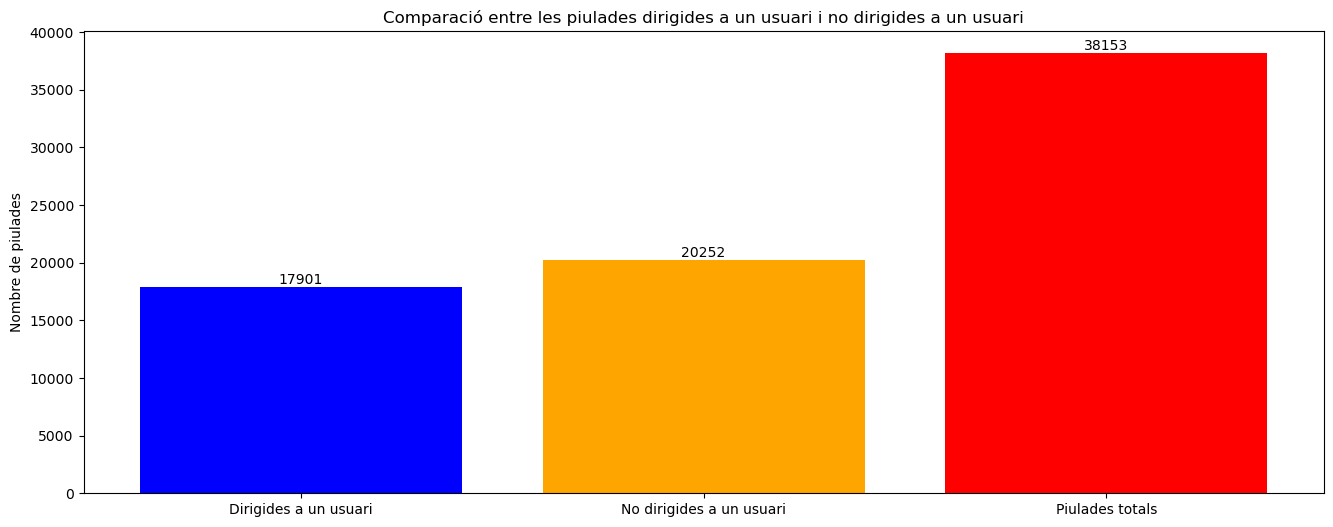

In [17]:
compare2values(df_tweets_train, piulades_usuari,
               ["Dirigides a un usuari", "No dirigides a un usuari", "Piulades totals"], 
               "Comparació entre les piulades dirigides a un usuari i no dirigides a un usuari",
               "Nombre de piulades")

Continuem estudiant les dades i ara observem que hi ha $17901$ piulades dirigides a algú i $20252$ que no. Això pot ser perqué la gent acostuma a comentar més i a barallar-se menys amb algú.

+ Quants *hashtags* ``#`` hi ha a cada categoria de *piulades*?

Compteu els ``#`` que vagin seguits d'alguna lletra o nombre ja que, com veiem a la [normativa](https://help.twitter.com/en/using-twitter/how-to-use-hashtags) de X, els ``#`` no poden contenir cap mena de signe de puntuació.

In [18]:
# Patró per trobar qualsevol hashtag
patro_hashtag = r"#"

# Copy the dataset to don't loose sensible info
data = df.copy()

# Count hashtags per row
data['total_hashtags_count'] = data["tweet_text"].str.findall(patro_hashtag).apply(len)
display(data)

,tweet_text,cyberbullying_type,total_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0
...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0


In [19]:
# Patró del hashtag filtrat
patro_hashtag = r"#[A-Za-z0-9]+"

# Count valid hashtags per row
data['valid_hashtags'] = data['tweet_text'].str.findall(patro_hashtag)
data['valid_hashtags_count'] = data['valid_hashtags'].apply(len)

# Total hashtag count across all rows
total_hashtags = data['valid_hashtags_count'].sum()

In [20]:
display(data)

,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,"[#katandandre, #mkr]",2
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0,[],0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0,[],0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0,[],0
...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,[],0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,[],0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,[],0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,[],0


In [21]:
hcount = data.groupby("cyberbullying_type")['valid_hashtags_count'].sum()
display(hcount)

cyberbullying_type
age                     728
ethnicity              1112
gender                 2691
not_cyberbullying      3265
other_cyberbullying    1625
religion               1798
Name: valid_hashtags_count, dtype: int64

+ Fes un histograma que representi aquesta distribució?

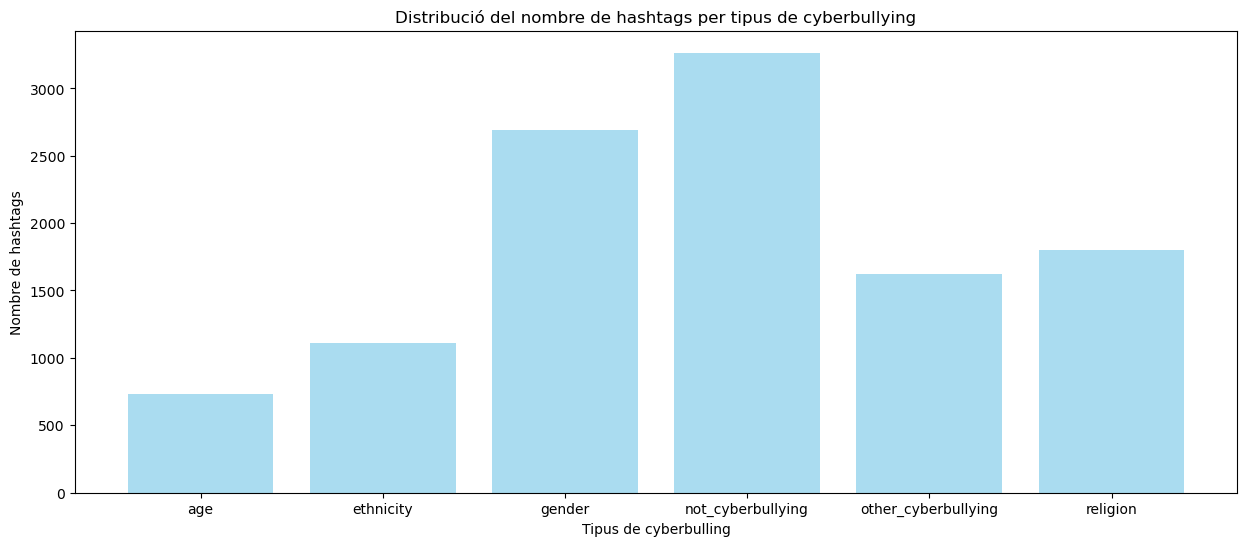

In [22]:
# Creem el gràfic
plt.figure(figsize=(15,6))

# Fem l'histograma
plt.bar(hcount.index, hcount.values, color='skyblue', alpha=0.7)

# Anomenem els eixos segons els valors passats per paràmetre
plt.xlabel("Tipus de cyberbulling")
plt.ylabel("Nombre de hashtags")
plt.title("Distribució del nombre de hashtags per tipus de cyberbullying")

# Mostrem els valors a l'eix x
plt.xticks(hcount.index)

plt.show()

Podem veure que els hashtags segueixen una tendencia similar als comentaris dels usuaris.

+ Comproveu a continuació quantes vegades hi ha un ús invàlid dels ``#``, per exemple ``##`` o ``#@``, on, si no tinguessim en compte la restriccio imposada, hauriem contat 2 ``#`` a ``##`` o 1 ``#`` a ``#@``, quan en realitat son 1 i 0 respectivament.

In [23]:
# Invalid hashtag count
data['invalid_hashtags_count'] = data['total_hashtags_count'] - data['valid_hashtags_count']
display(data)

,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,"[#katandandre, #mkr]",2,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0,[],0,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0,[],0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0,[],0,0
...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,[],0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,[],0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,[],0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,[],0,0


In [24]:
print(data['invalid_hashtags_count'].sum())

102


+ Quantes *piulades* vàlides hi ha de cada categoria?

In [25]:
# Valid tweet is not mention-invalid and not hashtag-invalid
reg = r"@[^A-Za-z0-9_]"
# reg = r'@[^A-Za-z0-9_]{0,2}|@[^A-Za-z0-9_]{17,}'
invalid_mentions = data[data['tweet_text'].str.contains(reg, regex=True)].index
invalid_hashtags = data[data['invalid_hashtags_count'] > 0].index

In [26]:
invalid_tweets = invalid_mentions.union(invalid_hashtags)
valid_tweets = data.drop(invalid_tweets, axis=0)
grouped_tweets = valid_tweets.groupby("cyberbullying_type").size()
display(grouped_tweets)

cyberbullying_type
age                    7980
ethnicity              7951
gender                 7926
not_cyberbullying      7912
other_cyberbullying    7791
religion               7984
dtype: int64

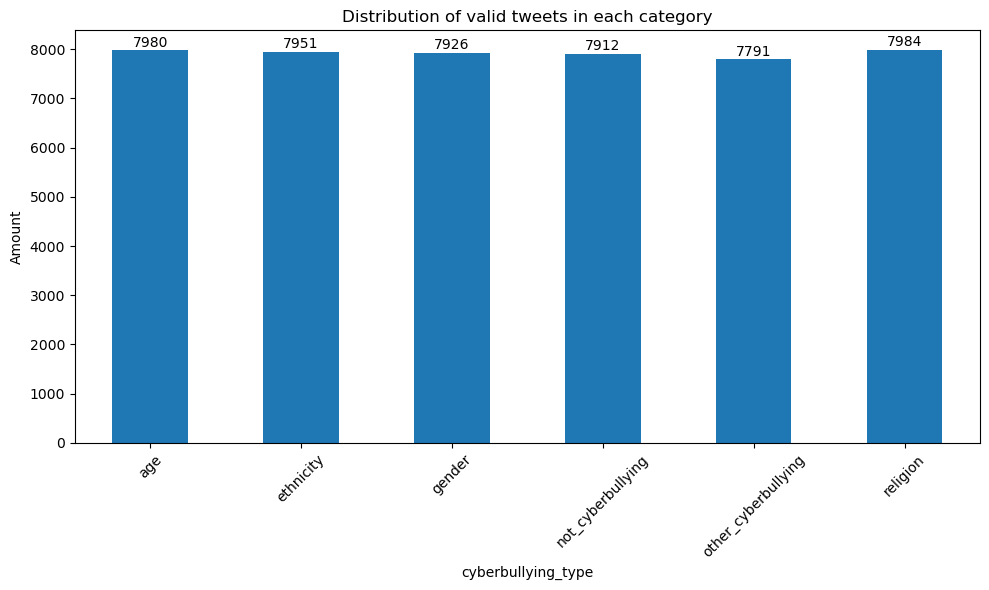

In [27]:
# Fem plot dels resultats per poder veure que està passant
plt.figure(figsize=(10, 6))

ax = grouped_tweets.plot(kind='bar')

# Afegim els valors a sobre de la barra
for i, value in enumerate(grouped_tweets):
    plt.text(i, value + 10,  # Ajusta la posición vertical sumando un pequeño valor
             str(value), 
             ha='center', va='bottom', fontsize=10)

plt.title('Distribution of valid tweets in each category')
plt.ylabel('Amount')
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

+ Quantes *piulades* de la categoria `not_cyberbullying` és dirigeixen a un usuari?
+ Quantes *piulades* de totes les altres categories és dirigeixen a un usuari?

In [28]:
reg = r'@[A-Za-z0-9_]{5,15}'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]

# We will try to delete some invalid mentions that will not appear, so we ignore errors
valid_mentions = mentions.drop(invalid_tweets, axis=0, errors='ignore')

test_mentions = valid_mentions[valid_mentions["cyberbullying_type"]=="not_cyberbullying"]
test2_mentions = valid_mentions[valid_mentions["cyberbullying_type"]!="not_cyberbullying"]

display(test_mentions)

display(test2_mentions)

grouped_valid_mentions = valid_mentions.groupby("cyberbullying_type").size()
display(grouped_valid_mentions)

,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0,[],0,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0,[],0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0,[],0,0
5,"@Raja5aab @Quickieleaks Yes, the test of god i...",not_cyberbullying,0,[],0,0
8,@stockputout everything but mostly my priest,not_cyberbullying,0,[],0,0
...,...,...,...,...,...,...
7934,@MetroidThief @deathofrats01 his face is a bit...,not_cyberbullying,0,[],0,0
7935,Email #JoanneMillerMP police@ministerial.qld....,not_cyberbullying,1,[#JoanneMillerMP],1,0
7936,Good luck all #MKR teams ! Such a beautiful BB...,not_cyberbullying,1,[#MKR],1,0
7937,@Goddess_Slim Is your volume turned up? Not yo...,not_cyberbullying,0,[],0,0


,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
7947,"@ManhattaKnight I mean he's gay, but he uses g...",gender,0,[],0,0
7948,RT @Raul_Novoa16: @AliciaBernardez @Alex_Aim @...,gender,0,[],0,0
7950,"@coiny Also, it's hard to take a company serio...",gender,0,[],0,0
7953,RT @mcclure111: #DontDateSJWs #ThatWouldBeAVio...,gender,2,"[#DontDateSJWs, #ThatWouldBeAViolationOfTheRes...",2,0
7955,Simple things please simple minds. @pumpkinkin...,gender,0,[],0,0
...,...,...,...,...,...,...
47673,“@ranran_42: EVERYONE STAYS HATIN SORRY I LIKE...,ethnicity,0,[],0,0
47685,@KeithBishop64 Very true. It was a nice show t...,ethnicity,0,[],0,0
47686,@YourFavWhiteGuy shut the fuck upAbout your du...,ethnicity,0,[],0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,[],0,0


cyberbullying_type
age                     326
ethnicity              3333
gender                 3176
not_cyberbullying      4094
other_cyberbullying    4732
religion               2177
dtype: int64

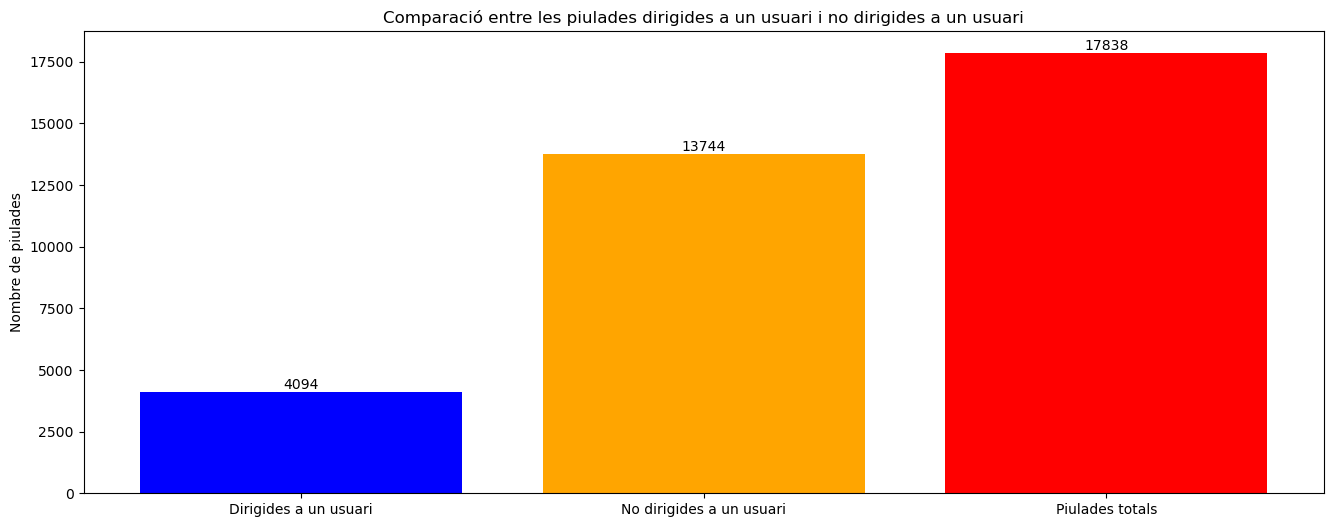

In [29]:
compare2values(valid_mentions, test_mentions,
               ["Dirigides a un usuari", "No dirigides a un usuari", "Piulades totals"], 
               "Comparació entre les piulades dirigides a un usuari i no dirigides a un usuari",
               "Nombre de piulades")

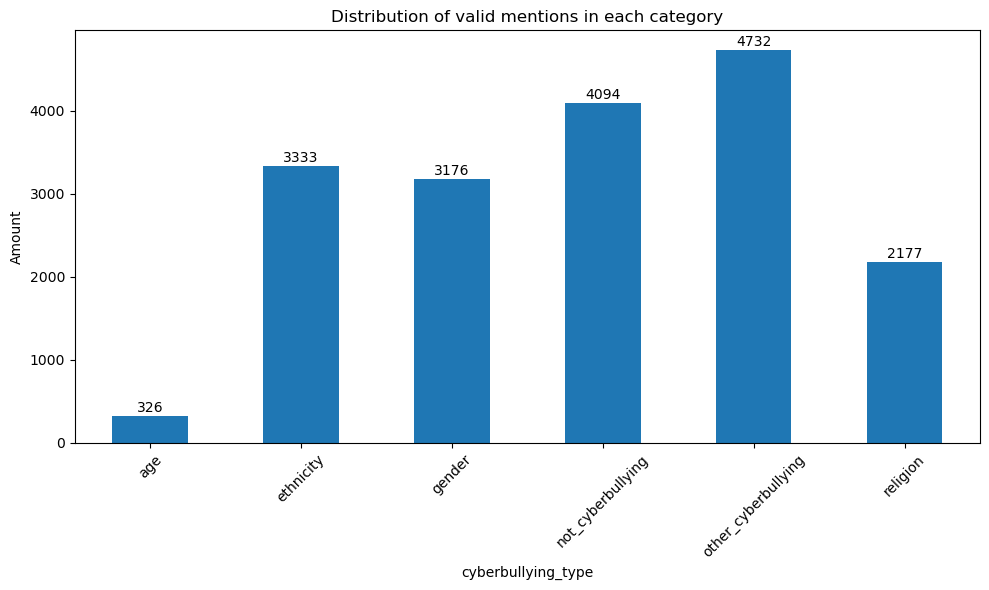

In [30]:
# Fem plot dels resultats per poder veure que està passant
plt.figure(figsize=(10, 6))

ax = grouped_valid_mentions.plot(kind="bar")

# Afegim els valors a sobre de la barra
for i, value in enumerate(grouped_valid_mentions):
    plt.text(i, value + 10,  # Ajusta la posición vertical sumando un pequeño valor
             str(value), 
             ha='center', va='bottom', fontsize=10)

plt.title('Distribution of valid mentions in each category')
plt.ylabel('Amount')
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

+ Calculeu altres coses que penseu que poden ser rellevants (usuaris més mencionats, *hashtags* més comuns per cada categoria, etc.).

+ Mostrem els hashtags més comuns per categoria

In [31]:
# Extreure hashtags
patro_hashtag_valid = r"#([A-Za-z0-9]+)"
hashtags = df_tweets_train["tweet_text"].str.extractall(patro_hashtag_valid)
hashtags.columns = ["hashtag"]

# Afegir la categoria de cada piulada
hashtags["categoria"] = df_tweets_train.loc[hashtags.index.get_level_values(0), "cyberbullying_type"].values

# Comptar hashtags més comuns per categoria
hashtags_mes_comuns = hashtags.groupby("categoria")["hashtag"].value_counts().groupby(level=0).head(10)
print("Hashtags més comuns per categoria:")
print(hashtags_mes_comuns)

Hashtags més comuns per categoria:
categoria            hashtag             
age                  MG                       13
                     SFFpit                   13
                     bullying                 11
                     TheBachelor              10
                     school                    7
                     BachelorInParadiseAU      6
                     MAGA                      6
                     bully                     6
                     F                         5
                     WhyIDontLikeTrump         5
ethnicity            racism                   21
                     coon                     18
                     nigger                   13
                     niggers                   9
                     BlackLivesMatter          8
                     Coon                      8
                     Racism                    8
                     Obama                     7
                     disgusting          

+ Molt millor si ho podem visualitzar els hashtags per categoria

,categoria,hashtag,count
0,age,MG,13
1,age,SFFpit,13
2,age,bullying,11
3,age,TheBachelor,10
4,age,school,7
5,age,BachelorInParadiseAU,6
6,age,MAGA,6
7,age,bully,6
8,age,F,5
9,age,WhyIDontLikeTrump,5


,categoria,hashtag,count
0,age,mg,13
1,age,sffpit,13
2,age,bullying,11
3,age,thebachelor,10
4,age,school,7
5,age,bachelorinparadiseau,6
6,age,maga,6
7,age,bully,6
8,age,f,5
9,age,whyidontliketrump,5


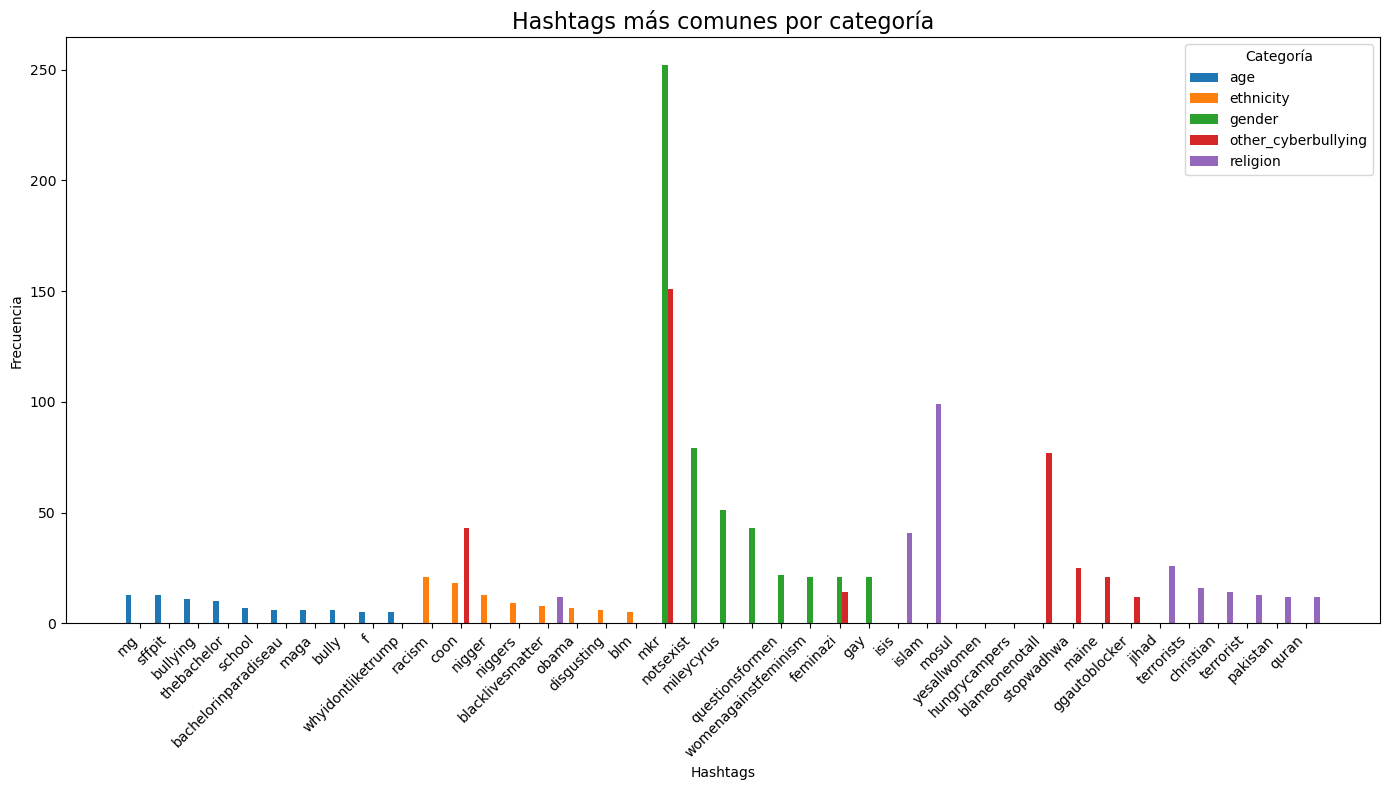

In [32]:
# Convertim les dades a df
# hashtags_mes_comuns =  data["tweet_text"].apply(standarize_text)
# display(hashtags_mes_comuns)
hashtags_mes_comuns_df = hashtags_mes_comuns.reset_index()
display(hashtags_mes_comuns_df)
hashtags_mes_comuns_df["hashtag"] = hashtags_mes_comuns_df["hashtag"].apply(standarize_text)
display(hashtags_mes_comuns_df)
hashtags_mes_comuns_df.columns = ['categoria', 'hashtag', 'count']

# Obtenim les categories i els hashtags
categorias = [categoria for categoria in hashtags_mes_comuns_df['categoria'].unique() if categoria != "not_cyberbullying"]
hashtags = hashtags_mes_comuns_df['hashtag'].unique()

# Creem un gràfic de barres agrupades
plt.figure(figsize=(14, 8))
bar_width = 0.2
x_indices = np.arange(len(hashtags))

for i, categoria in enumerate(categorias):
    # Filtrar dades
    subset = hashtags_mes_comuns_df[hashtags_mes_comuns_df['categoria'] == categoria]
    # Mapejar hashtags
    indices = [np.where(hashtags == ht)[0][0] for ht in subset['hashtag']]
    plt.bar(x_indices[indices] + i * bar_width, subset['count'], width=bar_width, label=categoria)

# Personalitzar el gràfic
plt.title('Hashtags más comunes por categoría', fontsize=16)
plt.xlabel('Hashtags')
plt.ylabel('Frecuencia')
plt.xticks(x_indices + bar_width * (len(categorias) - 1) / 2, hashtags, rotation=45, ha='right', fontsize=10)
plt.legend(title='Categoría')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

+ Ara no distinguirem per categoria, tan sols el recompte total

In [33]:
used_hashtags = data.explode("valid_hashtags").groupby("valid_hashtags").size()
used_hashtags = used_hashtags.sort_values(ascending=False)
display(used_hashtags)

valid_hashtags
#MKR                         1319
#mkr                         1192
#Islam                        145
#BlameOneNotAll               117
#notsexist                    105
                             ... 
#youtube                        1
#youwont1v1me                   1
#yshhtb                         1
#zacksnydersjusticeleague       1
#zimmermantrial                 1
Length: 4912, dtype: int64

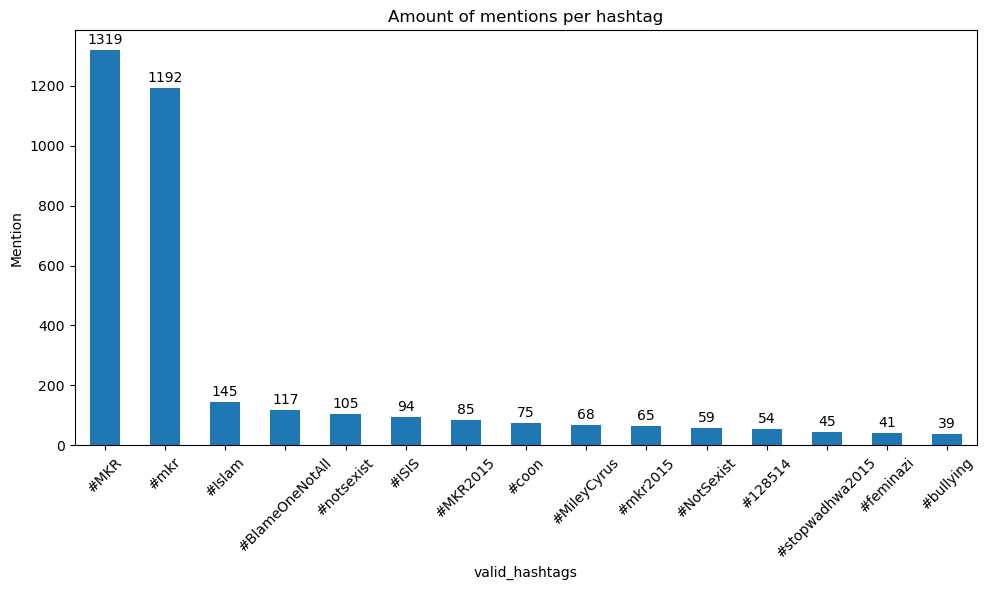

In [34]:
# Fem plot dels resultats per poder veure que està passant
plt.figure(figsize=(10, 6))

aux_df = used_hashtags.head(15)
ax = aux_df.plot(kind="bar")

# Afegim els valors a sobre de la barra
for i, value in enumerate(aux_df):
    plt.text(i, value + 10,  # Ajusta la posición vertical sumando un pequeño valor
             str(value), 
             ha='center', va='bottom', fontsize=10)

plt.title('Amount of mentions per hashtag')
plt.ylabel('Mention')
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

My Kitchen Rules (often abbreviated as MKR) is an Australian competitive cooking game show broadcast on the Seven Network since 2010. The show is currently hosted and judged by chefs Manu Feildel and Colin Fassnidge, with Feildel being the only judge who has appeared in every season of the show.

In [35]:
# Alternative that uses pandas
display(data)
used_hashtags = data.explode("valid_hashtags")
display(used_hashtags)
used_hashtags["valid_hashtags"] = used_hashtags["valid_hashtags"].str.lower()
display(used_hashtags)
used_hashtags = used_hashtags.pivot_table(index='valid_hashtags', columns='cyberbullying_type', aggfunc='size', fill_value=0)
display(used_hashtags)
used_hashtags['total'] = used_hashtags.sum(axis=1)
display(used_hashtags)

,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,"[#katandandre, #mkr]",2,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0,[],0,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0,[],0,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0,[],0,0
...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,[],0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,[],0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,[],0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,[],0,0


,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,#katandandre,2,0
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,#mkr,2,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#aussietv,10,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#MKR,10,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#theblock,10,0
...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,NaN,0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,NaN,0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,NaN,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,NaN,0,0


,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,#katandandre,2,0
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,#mkr,2,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#aussietv,10,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#mkr,10,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,#theblock,10,0
...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,NaN,0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,NaN,0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,NaN,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,NaN,0,0


cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion
valid_hashtags,,,,,,
#00,0,1,0,0,0,0
#039,0,0,2,0,0,0
#1,1,5,2,3,4,0
#100factsaboutme,0,0,0,0,2,0
#100thingsthatmakemehappy,0,0,1,0,0,0
...,...,...,...,...,...,...
#zimmerman,0,2,0,0,0,0
#zimmermantrial,0,1,0,0,0,0
#zionist,0,0,0,0,0,2


cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion,total
valid_hashtags,,,,,,,
#00,0,1,0,0,0,0,1
#039,0,0,2,0,0,0,2
#1,1,5,2,3,4,0,15
#100factsaboutme,0,0,0,0,2,0,2
#100thingsthatmakemehappy,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...
#zimmerman,0,2,0,0,0,0,2
#zimmermantrial,0,1,0,0,0,0,1
#zionist,0,0,0,0,0,2,2


In [36]:
# 15 more used hashtags, and now by category
used_hashtags.sort_values(by='total', ascending=False)[:15]

cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion,total
valid_hashtags,,,,,,,
#mkr,0,2,633,1602,285,2,2524
#notsexist,0,0,163,5,0,0,168
#islam,1,2,2,21,0,133,159
#mkr2015,0,0,50,82,18,0,150
#blameonenotall,0,1,17,0,109,0,127
#coon,0,33,5,0,74,0,112
#isis,0,1,0,37,3,59,100
#mileycyrus,0,0,69,0,0,0,69
#stopwadhwa2015,0,0,1,18,36,0,55


+ Mostrem els usuaris més mencionats

In [37]:
reg = r'@[A-Za-z0-9_]{5,15}'

data['valid_mentions'] = data['tweet_text'].str.findall(reg)
data['valid_mentions_count'] = data['valid_mentions'].apply(len)
data['total_mentions_count'] = data['tweet_text'].str.findall(r"@").apply(len)
data['invalid_mentions_count'] = data['total_mentions_count'] - data['valid_mentions_count']
display(data)

,tweet_text,cyberbullying_type,total_hashtags_count,valid_hashtags,valid_hashtags_count,invalid_hashtags_count,valid_mentions,valid_mentions_count,total_mentions_count,invalid_mentions_count
0,"In other words #katandandre, your food was cra...",not_cyberbullying,2,"[#katandandre, #mkr]",2,0,[],0,0,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,10,"[#aussietv, #MKR, #theblock, #ImACelebrityAU, ...",10,0,[],0,0,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0,[],0,0,[@XochitlSuckkks],1,1,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0,[],0,0,[@Jason_Gio],1,1,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0,[],0,0,[@RudhoeEnglish],1,1,0
...,...,...,...,...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity,0,[],0,0,[],0,0,0
47688,Turner did not withhold his disappointment. Tu...,ethnicity,0,[],0,0,[],0,0,0
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity,0,[],0,0,[],0,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity,0,[],0,0,[@therealexel],1,1,0


In [38]:
# Take the first idea for hashtags and use it for users
used_mentions = data.explode("valid_mentions").groupby("valid_mentions").size()
used_mentions = used_mentions.sort_values(ascending=False)
display(used_mentions)

valid_mentions
@tayyoung_         958
@freebsdgirl       233
@MaxBlumenthal     161
@mykitchenrules    115
@ChrisWarcraft     104
                  ... 
@zellieimani         1
@zeke4real           1
@zaytunacollege      1
@zaynmetro           1
@zandermercury       1
Length: 13416, dtype: int64

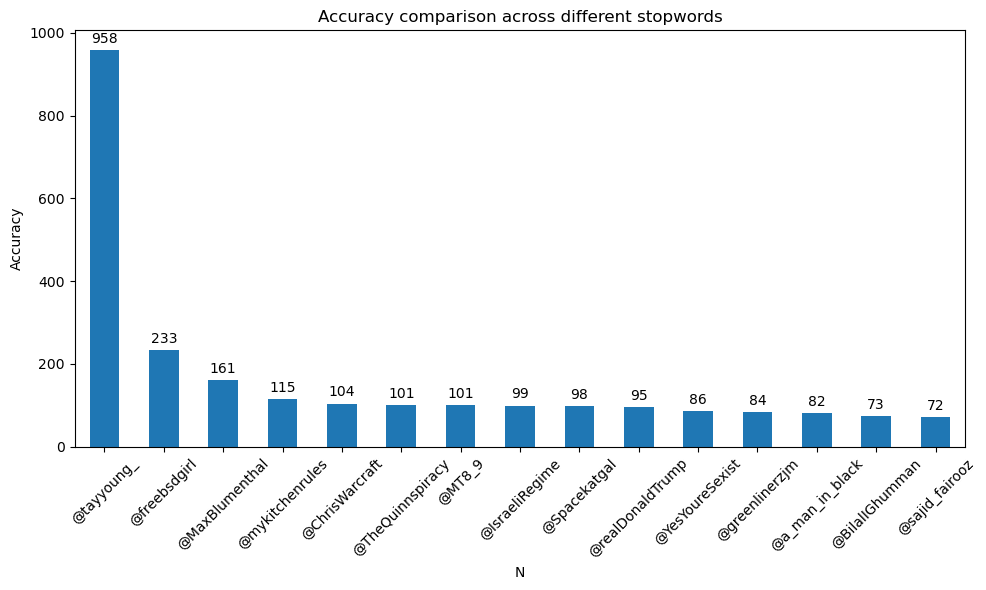

In [39]:
# Fem plot dels resultats per poder veure que està passant
plt.figure(figsize=(10, 6))

aux_df = used_mentions.head(15)
ax = aux_df.plot(kind="bar")

# Afegim els valors a sobre de la barra
for i, value in enumerate(aux_df):
    plt.text(i, value + 10,  # Ajusta la posición vertical sumando un pequeño valor
             str(value), 
             ha='center', va='bottom', fontsize=10)

plt.title('Accuracy comparison across different stopwords')
plt.xlabel('N')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [40]:
# We can even use the second idea for hashtags to see mentions by category of cyberbullying
used_mentions = data.explode("valid_mentions")
used_mentions = used_mentions.pivot_table(index='valid_mentions', columns='cyberbullying_type', aggfunc='size', fill_value=0)
used_mentions['total'] = used_mentions.sum(axis=1)
used_mentions.sort_values(by='total', ascending=False)[:15]

cyberbullying_type,age,ethnicity,gender,not_cyberbullying,other_cyberbullying,religion,total
valid_mentions,,,,,,,
@tayyoung_,0,958,0,0,0,0,958
@freebsdgirl,0,0,7,75,151,0,233
@MaxBlumenthal,0,0,1,41,0,119,161
@mykitchenrules,0,0,30,67,18,0,115
@ChrisWarcraft,0,0,12,23,69,0,104
@TheQuinnspiracy,0,0,0,25,76,0,101
@MT8_9,0,0,89,7,5,0,101
@IsraeliRegime,0,0,0,17,0,82,99
@Spacekatgal,0,0,1,34,63,0,98


In [41]:
# As we can see, @tayyoung_ and his/her network are pretty disrespectful individuals
reg = r'@tayyoung_'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]
display(mentions['tweet_text'])

39732    Fuck u bitch RT @tayyoung_: FUCK OBAMA, dumb a...
39748    @D_Paid: @Twin_Thing_Two: Y'all see this thoug...
39750    You a racist ass bitch and dat same dumb ass n...
39767    @tayyoung_: FUCK OBAMA, dumb ass nigger You ma...
39771    FUCK YOU BITCH!! he got 4 more yrs, get used t...
                               ...                        
47660    “@tayyoung_: FUCK OBAMA, dumb ass nigger”&lt;&...
47661    fuck you fat white bitch. RT @tayyoung_: FUCK ...
47663    You ain't get no Dick tonight so you mad at th...
47670    RT @Mr200taxnjckson: Taylor on a scale from cr...
47672    A Harvard JD doesn't imply "dumb" RT @StaxxFif...
Name: tweet_text, Length: 957, dtype: object

In [42]:
# Honorable mention to the 95 mentions of Donald Trump
reg = r'@realDonaldTrump'
mentions = data[data['tweet_text'].str.contains(reg, regex=True)]
display(mentions['tweet_text'])

13718    I have to quit being tactful @SenatorBraun @Se...
14195    Ridiculousness. I did not hear her click conde...
14744    Anyone else hear the female reporter call Kayl...
16221    Buhari should be in prison @POTUS @realDonaldT...
16450    I’ve got breaking news for you. If you support...
                               ...                        
45196    The “other “ “you don’t look like u belong” #A...
45487    @realDonaldTrump YO DUMB FUCK! STOP YOUR BULLS...
46286    Instead of using Twitter to extend condolences...
46555    Is my dad a brainwashed republican; yes! Does ...
47298    #NancyPelosiROCKS @MSNBC @CNNPolitics She stoo...
Name: tweet_text, Length: 95, dtype: object

### 2. Comptar paraules

In [43]:
# No modificar aquesta cel·la, s'encarrega de fer el procés més eficient.
# Intenteu entendre quà fa aquesta cel·la
def memo(f):
    class memodict(dict):
        def __init__(self, f):
            self.f = f
        def __call__(self, *args):
            return self[args]
        def __missing__(self, key):
            ret = self[key] = self.f(*key)
            return ret
    return memodict(f)

El primer que haurem d'implementar és la funció ``standardize`` que estandaritzarà les paraules.

#### EXERCICI 2: 

+ Empleneu la funció següent que, donada una paraula, la estandaritzi les paraules passant tots els caràcters a minúscules.

**Observació:** Podeu considerar diverses possibilitats per aquesta funció:
* Només canviar les lletres majúscules per minúscules
* Eliminar tots els símbols que no siguin @, # i _ (i substituïr-los per un espai)
* Eliminar tots els símbols (i substituïr-los per un espai)
* etc.

El mòdul `re` de Python és especialment útil en aquest punt. 

Trieu aquella possibilitat que dóna millor resultats a l'exercici 7!

In [44]:
@memo    
def standardize(word):
    """
    :param word: paraula a estandaritzar
    :return : paraula estandaritzada
    """
    # Convertim a minúscules
    word = word.lower()
    
    # Eliminem els simbols no permesos
    word = re.sub(r"[^a-z0-9@#_ ]", "", word)

    # Eliminem espais innecessaris
    word = re.sub(r"\s+", " ", word).strip()
    
    # Remove URLs
    word = re.sub(r'^https?:\/\/.[\r\n]', '', word)
    
    # Remove punctuation and others
    word = re.sub(r'[^a-z\s]', '', word)
    
    # Remove repeated characters
    re.sub(r'(.)\1{3,}', r'\1', word)
    # Remove extra spaces
    word = re.sub(r'\s+', ' ', word).strip()
    
    return word

In [45]:
standardize("Taller DELS noUS USOS")

'taller dels nous usos'

In [46]:
# Proba més exhaustiva
standardize("   Tal$$$$ler %DELS          noUS =USOS")

'taller dels nous usos'

In [47]:
# Veiem que standardize és de la clase memo, per tant no es callable com una funció def normal
print(f"standardize object: {standardize}")

print(f"standardize type: {type(standardize)}")

# Això ens donarà problemes més endavant per processar les dades
# Per solucionar això definim standarize_text() a la següent cel·la

standardize object: {('Taller DELS noUS USOS',): 'taller dels nous usos', ('   Tal$$$$ler %DELS          noUS =USOS',): 'taller dels nous usos'}
standardize type: <class '__main__.memo.<locals>.memodict'>


#### EXERCICI 3: 

+ Feu una funció ``count_words`` que construeixi un diccionari que contingui totes les paraules que s'han trobat al dataset, tot indicant el total de cops que ha aparegut cadascuna i el nombre de piulades on apareix. 

El resultat ha de ser un diccionari d'aquest tipus (no necessàriament amb aquest valors):

```python
{
    'memory' : {'n_ocur': 88, 'n_piu': 76},
    'best': {'n_ocur': 123, 'n_piu': 65},
    ...
}
```

In [48]:
# Creem aquesta funció auxiliar per cridar standardize
def standarize_text(word):
    """
    :param word: paraula a estandaritzar
    :return : paraula estandaritzada utilitzant standardize
    """
    return standardize(word)

In [49]:
# Ara si, el tipus de standarize_text és function i es pot executar
print(f"standarize_text type: {type(standarize_text)}")

standarize_text type: <class 'function'>


In [50]:
def count_words(df):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {word : {n_ocur: valor, n_tweets: valor}, ...}
    """
    # Utilizem apply amb la funció standarize_text() que acabem de definir
    standarizedText =  df["tweet_text"].apply(standarize_text)
    
    # IDEA: Crear un df amb totes les paraules i fer un value_counts()
    # Després tornarem al df original y comptarem els tweets on surt cada paraula
    
    # Combinem tots els tweets en un únic text i dividim en paraules
    all_words = " ".join(standarizedText).split(" ")

    # Comptar totes les ocurrències de paraules (n_ocur)
    word_count = pd.Series(all_words).value_counts()

    # Comptar en quants tweets apareix cada paraula (n_piu)
    # Convertim cada tweet en un conjunt de paraules úniques
    unique_words_per_tweet = standarizedText.apply(lambda x: set(x.split()))
    tweet_count = pd.Series([word for tweet in unique_words_per_tweet for word in tweet]).value_counts()
    
    # Construim el diccionari directament
    dicc = {
        word: {"n_ocur": word_count[word], "n_piu": tweet_count[word]}
        for word in word_count.index if word.strip()
    }

    return dicc

In [51]:
dicc_text = count_words(df_tweets_train)
print (len(dicc_text))
print("'rape':",dicc_text['rape'])

55904
'rape': {'n_ocur': np.int64(3391), 'n_piu': np.int64(3142)}


### 3. Comptar paraules per cada categoria de piulada

In [52]:
df_tweets_train.head()

,tweet_text,cyberbullying_type
40865,@HeyIts_Jayla @ryan_temple goodone dumb nigger...,ethnicity
33136,I bullied them in high school and I’ll bully t...,age
22287,"My mother, when pokemon first came out: oh HEL...",religion
2566,If 2 #mkr contestants were to be ousted by Kat...,not_cyberbullying
14340,RT @DanielSheppard5: I felt so out of place at...,gender


#### EXERCICI 4: 

+ Fent servir la funció que se us dona a continuació (`eachTopic`), apliqueu-la per tal de comptar les paraules que s'han trobat i la seva ocurrència segregant ara per categoria.

El resultat ha de ser un diccionari d'aquest tipus (no necessàriament amb aquest valors):

```python
{
    'ethnicity': {
        'race' : {'n_ocur': 88, 'n_piu': 76},
        'what': {'n_ocur': 123, 'n_piu': 65}
        ...
    },
    ...
    'gender': {
        'jokes' : {'n_ocur': 18, 'n_piu': 17},
        'you': {'n_ocur': 154, 'n_piu': 66}
    }
    ...
}
```

In [53]:
def count_words_categories(df):
    """
    Funció que ha de constuir un diccionari que conté la freqüència de les 
    paraules i el número de piulades on ha aparegut. 
    Aquesta informació ha de ser dividida per diferents categories de cyberbullying.
    
    :param df: DataFrame amb les piulades i la informació associada
    :return : Diccionari amb el format {label : {word : {n_ocur: valor, n_news: valor} } }
    """
    words_topic = {}

    def eachTopic(group):
        # Count words on this topic and save to dictionary
        words_topic[group['cyberbullying_type'].iloc[0]] = count_words(group)
        
    # IDEA: Agafar tots els tipus de cyberbullying
    # i cridar la funció eachTopic per cadascun d'ells
    categories = df["cyberbullying_type"].unique()

    for category in categories:
        data = df[df["cyberbullying_type"] == category]
        eachTopic(data)
    
    return words_topic

In [54]:
words_categories = count_words_categories(df_tweets_train)
print ("Categories:", len(words_categories))
print ("La paraula 'muslims' a la categoria 'religion':", words_categories["religion"]['muslims'])

Categories: 6
La paraula 'muslims' a la categoria 'religion': {'n_ocur': np.int64(1881), 'n_piu': np.int64(1663)}


### 4. Paraules més freqüents a les piulades


**El problema de com escollir el vector de carecterístiques**

L'elecció de les paraules que formen el vector de característiques és un pas crític. En funció de com de bona sigui aquesta descripció, millor funcionarà el sistema. Tot i que us deixem a vosaltres la política de creació del vector de característiques us donem una pista: una possible estratègia és agafar aquelles paraules que apareixen entre en un 10 i un 50 percent del total de piludades (sense tenir en compte la categoria). És a dir, paraules que no són ni massa freqüents ni massa poc. Podeu experimentar variant aquests valors.

Una altra estratègia interessant és eliminar "stop words".

#### EXERCICI 5: 

+ Feu una funció ``topNwords`` que crei un diccionari amb les N paraules més representatives (les que apareixen amb més freqüència) de cadascuna de les categories de *cyberbullying* (Tenint en compte que haureu tret aquelles paraules que apareixen en la majoria de piulades, així com també, les que únicament apareixen en un conjunt molt petit de piulades). Una pista de que aneu ben encaminats es que per cadascuna de les categories de *cyberbullying* obtingueu paraules rellevants per aquesta. Si no es així, vol dir que heu d'incrementar el nombre de paraules a saltar (*skip_top*).

El resultat serà un diccionari tipus (no necessàriament amb aquest valors):

```python
{
    'age': ['school', 'high', ...],
    ...
    'religion': ['muslims', 'christian',...]
    ...
}
```

+ Experimenteu omplint la llista `skip_top` amb aquelles paraules que penseu no tenen significat o relevancia per definir cada categoria. Podeu buscar informació sobre **stop words** a internet i definir varies llistes fins que penseu que obteniu una bona representació de paraules per categoria de `cyberbullying`.

In [55]:
def topNwords(df, words, N, skip=[]):
    """
    :param df: DataFrame amb les piulades i la informació associada
    :param words: diccionari amb les paraules i la seva frequencia
    :param N: número de paraules més representatives que volem considerar
    :return : Diccionari amb el format {categoria1: llista_top_words_cat_1,  
                                        categoria2: llista_top_words_cat_2, ...} 
    """
    top_words=dict()
    
    # IDEA: Iterar pel diccionari amb les paraules
    # i les ocurrencies i buscar les N més representatives
    
    # Guardem les categories de cyberbullying
    categories = df["cyberbullying_type"].unique()

    for category in categories:
        # Guardem la informació de cada categoria
        category_words = words[category]
                
        # Per totes les paraules de la categoria mirem si és vàlida
        filtered_words = {word: freq for word, freq in category_words.items() if word not in skip}

        # Ordenem les paraules per n_ocur de forma descendent
        sorted_words = sorted(filtered_words.items(), key=lambda x: x[1]["n_ocur"], reverse=True)

        # Seleccionem les N paraules més representatives
        top_category_words = [word for word, _ in sorted_words[:N]]

        # Afegim la llista al diccionari
        top_words[category] = top_category_words
    
    return top_words

### 5. Vector de Característiques

#### EXERCICI 6: 

Creeu el vector de característiques necessari per a fer l’entrenament del Naïve Bayes amb la funció ``create_features``.

El resultat serà un diccionari tipus (no necessàriament amb aquest valors):

```python
{
    0: np.array([0, 1, 1, 0, ...]),
    1: np.array([0, 1, 1, 1, ...]),
    ...
}
```

In [56]:
def create_features(df, top_words): 
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params top_words: ha de ser el diccionari que retorna topNWords
    :return : diccionari o pd.Series que conté un np.array per a 
        cadascuna de les piulades amb el vector de característiques corresponent.
    """

    # IDEA: Guardar totes les paraules úniques escrites i per cada
    # comentari veure si aquesta paraula surt o no.
    # Per fer això utilitzarem moltes llistes, 
    # set i list/set-comprehension. És fundamental (i de fet vam tenir problemes)
    # que es controlin bé els indexos perque es fan moltes iteracions
    # i és fàcil liar-la
    
    # Combinar totes les paraules top de totes les categories
    unique_words = list(set(word for words in top_words.values() for word in words))

    # Crear un índex per accedir ràpidament a les paraules
    word_index = {word: idx for idx, word in enumerate(unique_words)}
    
    # Inicialitzar el diccionari de vectors de característiques
    dict_feat_vector = {}

    # Utilizem apply amb standarize_text
    standarizedText =  df["tweet_text"].apply(standarize_text)

    # Agafem l'index i el tweet
    # És important agafar aquest index, sinó perdem 
    # consistencia amb la resta de la taula
    for idx, tweet in standarizedText.items():
        # Dividim el tweet en paraules
        tweet_words = set(tweet.split())
        
        # Inicialitzem el vector de característiques
        feature_vector = np.zeros(len(unique_words), dtype=int)
        
        # Marquem les paraules que hi ha al tweet
        for word in tweet_words:
            if word in word_index:
                feature_vector[word_index[word]] = 1
        
        # Assignem el vector
        dict_feat_vector[idx] = feature_vector
    
    return dict_feat_vector

In [57]:
# Definim les skip_top com una llista buida, això ho canviarem més endavant
# però la idea és veure la precisió "natural" del predictor.
skip_top=[]
print(f"Hem considerat {len(skip_top)} stopwords diferents")
print(skip_top)

Hem considerat 0 stopwords diferents
[]


In [58]:
N = 30 # Aquest parametre el podem canviar i fer proves per avaluar quin és el millor valor. 
words_categories = count_words_categories(df_tweets_train)
top_words = topNwords(df_tweets_train, words_categories, N, skip_top)
dict_feat_vector = create_features(df_tweets_train, top_words)

In [59]:
len(dict_feat_vector)

38153

### 6. El classificador Naïve Bayes

Un cop tenim una representació necessitem un procés d'aprenentatge que ens permeti passar de la descripció a una categoria. 
En aquest lliurament farem servir el classificador Naïve Bayes. 
Aquest classificador forma part de la família de classificadors probabilístics. 
La sortida d'un classificador probabilístic és un valor de probabilitat donat un exemple per cadascuna de les categories. 
La decisió final correspon a la categoria amb més probabilitat. 


Els classificadors probabilistics Bayesians es basen en el teorema de Bayes per realitzar els càlculs per estimar la probabilitat condicionada $p(y|x)$, on $y$ és la categoria i $\mathbf x$ les característiques de l'exemple.

La fòrmula de Bayes és fàcil de deduir. Sabem que:

$$ p(\mathbf x,y) = p(\mathbf x|y)p(y) = p(y|\mathbf x)p(\mathbf x)$$
d'on podem extreure que: 
$$ p(y|\mathbf x) = \frac{p(\mathbf x|y)p(y)}{p(\mathbf x)}$$


La millor categoria serà la que fa màxima la probabilitat $ p(y|\mathbf x)$ i per comparar aquests valors i saber quin és el màxim no cal calcular $p(\mathbf x)$ (que és constant). Per tant, considerarem que:
$$ p(y|\mathbf x) \approx p(y) · p(\mathbf x|y)$$


Les deduccions fins a aquest punt són vàlides per la majoria de classificadors Bayesians. 
Naïve Bayes es distingeix de la resta perquè imposa una condició encara més restrictiva. 
Considerem $\mathbf x=(x_1, \cdots, x_n)$ un conjunt d'$N$ variables aleatòries (en el nostre cas, les paraules seleccionades). 
Naïve Bayes assumeix que la probabilitat de la presència d'una paraula en una piulada és independent de la presència d'una altra i per tant podem escriure:
$$p(x_1,x_2,...,x_N | y) = p(x_1|y)p(x_2|y)...p(x_N|y)$$


Podem interpretar l'anterior equació de la següent forma: La probabilitat de que una piuldad descrita pel vector de característiques (0,1,0,1,1,1) sigui de la classe "gender" és proporcional al producte de la probabilitat que la primera paraula del vector no aparegui en les piulades sobre "gender" per la probabilitat que la segona paraula sí que hi aparegui, etc.


**Estimant les probabilitats marginals condicionades**

L'últim pas que ens queda és trobar el valor de les probabilitats condicionades. 
Farem servir la representació de $0$'s i $1$'s indicant que la paraula no apareix (0) o sí apareix (1) a la piulada. 

Per trobar el valor de la probabilitat condicionada farem servir una aproximació freqüentista a la probabilitat. 
Això vol dir que calcularem la freqüència d'aparició de cada paraula per a cada categoria. 
Aquest càlcul es fa dividint el nombre de piulades de la categoria en que apareix la paraula pel nombre total de piulades d'aquella categoria. 

En general:
$$p(x = \text{"school"} | y = C)= \frac{A}{B} $$
on $A$ és el número de piulades de la categoria $C$ on hi apareix la paraula 'school' i $B$ és el número total de piulades de la categoria $C$.


#### Punts delicats a tenir en compte.

**El problema de la probabilitat 0**

Si us hi fixeu bé, la probabilitat pot ser 0!!  Això vol dir, que si en una piulada no hi apareix una paraula, no pot ser classificada com cap tipus de *cyber bullying* (la presència del 0 al producte fa que el resultat sigui 0).

No sembla raonable que s'assigni o no en aquesta categoria segons si en la piulada hi apareix o no una única paraula. 
Per tant, el que s'acostuma a fer és donar una baixa probabilitat en comptes de zero. 

Una de les possibles solucions es fer servir la correcció de Laplace. Seguint l'exemple anterior la correcció de Laplace és:

$$p(x= \text{"school"} | y = C ) = \frac{A+1}{B+M}$$ 

on $M$ és el nombre de categories.

**El problema de l'"underflow"**

La valor que hem de calcular en el Naive Bayes és el resultat d'un producte. 
El nombre de caractéristiques del vector és el nombre de termes del producte. 
Aquests nombres són iguals o menors a 1 i n'hi ha molts, si els multipliquem entre ells el resultat serà massa petit per a representar-lo en un nombre de punt flotant i el càlcul acabarà sent reduït a zero. 

Per solucionar aquest problema en comptes d'operar fent multiplicacions, se sol passar a l'escala logarítmica i allà operar fent servir sumes en comptes de multiplicacions.

### Ús de logartimes:

Sabem que 
\begin{equation*}
p(x_1,x_2,...,x_N | y) = p(x_1|y)p(x_2|y)...p(x_N|y)
\end{equation*}
i volem trobar el valor màxim de $p(x_1|y)$. Com que la funció $\log(x)$ és injectiva en $\mathbb{R}^+$, els màxims de $x$ coincidiran amb els de $\log(x)$. De fet aplicar aquest argument és molt típic a Estadística per estalviar-se treballar amb productes d'exponencials.

Bé doncs, si volem maximitzar $p(x_1,x_2,...,x_N | y)$ podem aplicar logaritmes i ens queda
\begin{equation*}
\log(p(x_1,x_2,...,x_N | y)) = \log(p(x_1|y)p(x_2|y)...p(x_N|y)) = \log(p(x_1|y))+\log(p(x_2|y))+\dotsb+\log(p(x_N|y))
\end{equation*}

Si el vector de caraterístiques és $(0, 1,\dotsc)$ podem interpretar aquesta probabilitat com la probabilitat de que la primera paraula no aparegui, la segona sí, etc. Dit d'una altra manera, que $\log(1-p(x_1|y)) = \log(p(x_2|y)) = 1$. Per tant, per fer el càlcul el que farem és multiplicar el vector de característiques original per les $\log(\{\text{probabilitats}\})$ i el vector de característiques invertit per $\log(1-\{\text{probabilitats}\})$ i d'aquesta forma tenim en compte el fet de que la paraula aparegui o no respectivament.

Per tant, la fórmula que soluciona això és:
\begin{equation*}
\log(p(x_1,x_2,...,x_N | y)) = \sum_i v_i \log(p(x_i|y)) + (1-v_i)\log(1-p(x_i|y))
\end{equation*}

on $v_i\in\{0,1\}$ és l'$i$-éssim terme del vector de característiques (que és un vector binari).

                                                                                                                                      ☐

#### EXERCICI 7: 

+ Implementeu la funció d'aprenentatge del classificador Naïve Bayes (funció ``naive_bayes_learn()``) que retorni un diccionari amb estructura `{categoria: [P0, ..., PN]}` on la llista representa la probabilitat
marginal condicionada de cada paraula del vector de característiques per la categoria corresponent. 

+ Implementeu la funció ``naive_bayes`` que implementa el classificador. Noteu que aquesta funció está guiada i només haureu d'emplenar els espais on hem posat tres punts suspensius "#···".  

In [60]:
def naive_bayes_learn(df, feats):
    """
    :params df: DataFrame amb les piulades i la informació associada
    :params feats: vector de característiques de cada piulada
    :return : probabilitats marginals condicionades
    """
    # IDEA: Implementar la formula detallada adalt i trobar
    # A, B i M. Això ho farem jugant amb les categories
    # i amb el vector de característiques
    
    # Guardem les categories i la quantitat que hi ha
    categories = df["cyberbullying_type"].unique()

    # M és el total de categories
    M = len(categories)

    # Inicialitzem la estructura per guardar les probabilitats de cada categoria
    probs = {category: [] for category in categories}

    # Iterem per totes les categories per calcular les probabilitats
    for category in categories:
        # Agafem les piulades d'aquesta categoria i les guardem com una matriu
        category_indices = df[df["cyberbullying_type"] == category].index
        category_feats = np.array([feats[i] for i in category_indices])
        
        # A és total de piulades on surt una paraula en particular
        # Podem fer la suma per columnes perque cada fila és una piulada 
        # amb 0 o 1 a la posició i-ésima en cas de tener la paraula o no
        # per tant, fer la suma per columnes equival a comptar quantes piulades
        # tenen una paraula en particular
        A = np.sum(category_feats, axis=0)

        # B és el total de piulades hi ha a aquesta categoria
        B = len(category_feats)

        # Apliquem la correcció de Laplace
        probs[category] = (A + 1) / (B + M)

    return probs

In [61]:
import sys
from IPython import embed
def naive_bayes(df_train, feat_train, feat_test=None, df_test=None):
    """
    Funció que implementa el clasificador Naive_Bayes.
    
    Si df_test no és None, ha de calcular l'encert sobre les dades de test. És a dir,
    després de classificar feat_test ha de comparar la classificació amb la classe
    real i dir (print) quin percentatge d'encert ha obtingut.
    
    :param df_train: DataFrame amb les piulades que s'utilitzaran per l'entrenament
    :param feat_train: Diccionari amb els vectors de caracteristiques de cada tweet de l'entrenament
    :param feat_test: Diccionari amb els vectors de caracteristiques de cada tweet de test
    :param df_test: DataFrame amb les piulades que s'utilitzaran pel test
    
    :return : Una serie on l'index correspon amb els indexos de df_test i els valors són la
              classificació retornada per Naive Bayes
    """
    probs = naive_bayes_learn(df_train, feat_train)
    p_of_cat = count_words_categories(df_train)
    p_total = len(p_of_cat.keys())
    
    def eachFeats(row):
        id, feat = row
        p_max = float('-inf')
        p_cat = 0

        # IDEA: Agrupar tota la informació i aplicar les formules
        # observem a la demostració de l'us dels logaritmes
        # que s'ha detallat a la part superior        
        
        for category in probs:
            # Speed up by using numpy
            # inv is the inverse of features, 0 where 1 and 1 where 0
            inv_feat = 1 - feat
            
            # Probs * feats is the probability of being there, while
            # inv - inv * feat = 1 - (0, 1, 0... inverses) * probs, probability of not being there
            prob_there = probs[category]
            prob_not_there = 1 - probs[category]
            
            # Sum of logs [vs] underflow caused by mul of probs
            log_sum = np.sum(feat * np.log(prob_there) + inv_feat * np.log(prob_not_there))

            # Take the max, do it now to avoid extra-loops
            if log_sum > p_max:
                p_max = log_sum
                p_cat = category
        return id, p_cat
    
    data = map(eachFeats, feat_test.items())
    data = pd.Series(dict(data))
    correct = data == df_test['cyberbullying_type']
    print("Accuracy: {}".format(correct.sum() / correct.size))
    
    return correct.sum() / correct.size

In [62]:
N = 40 # Aquest parametre el podeu canviar i fer proves per avaluar quin és el millor valor. 

words_topics = count_words_categories(df_tweets_train)
top_words = topNwords(df_tweets_train, words_topics, N, skip_top)

feat_train = create_features(df_tweets_train, top_words)
feat_test = create_features(df_tweets_test, top_words)

In [63]:
accuracy = naive_bayes(df_tweets_train, feat_train, feat_test, df_tweets_test)

Accuracy: 0.7347730370059755


Haurieu d'obtenir una precisió del 67-70%. 

#### EXERCICI 8:

El possible procediment per tal d'aconseguir una major precisió seria el següent:
+ Es poden implementar diverses maneres d'escollir quines *stopwords* volem eliminar en les piuldades per a que no formin part dels vectors de característiques.
+ Avaluar quin conjunt d'*stopwords* retorna una precisió major per a N=40. 
+ Un cop tinguem el vector d'*stopwords* amb millors resultats, el testejarem per a diferents $N$'s per a veure quina és el nombre de *stopwords* òptim.

Feu una cerca a Intenet per trobar més estratègies i intenteu millorar l'*accuracy* que heu acosneguit fins ara.

Amb això podeu arribar a precisions superiors al 80%.

#### STOPWORDS:

Les **stopwords** (paraules buides) són termes comuns com "el", "una" o "en" que es filtren en el processament del llenguatge natural per millorar l'eficiència i la rellevància de l'anàlisi de text. Aquests mots no aporten gaire significat en el context del text i ocupen espai i temps de processament innecessari.

El tipus de stopwords són
1. Les paraules **comuns** i freqüents d'un idioma. Alguns exemples son "el", "la", etc
2. Paraules **personalitzades** que depenen molt de la tasca. Les paraules d'un camp especialitzat són bons exemples.
3. Els valors **numèrics**.
4. Els **caràcters únics** com per exemple  "a", "i", "s" o "x"
5. També poden ser **contextuals**, és a dir, buides en un context però rellevants en un altre.

Python ofereix diferents paquets per obtenir les **stopwords** de forma sencilla en un idioma. Els paquets més utilitzats són `NLTK`, `spaCy`, `Genism` o `SkLearn`. També es podria utilitzar una llista hardcodejada de GitHub. En el nostre cas agafarem tres llistes diferents: la primera serà una llista buida, la segona arran de `NLTK` i, per últim, una serà obtinguda de `GitHub`. La idea és tenir diferents proves amb diferents llistes de **stopwords** i veure quina dona millor rendiment.

Les fonts que hem fet servir per informar-nos han sigut:
1. https://www.geeksforgeeks.org/removing-stop-words-nltk-python/
2. https://medium.com/@yashj302/stopwords-nlp-python-4aa57dc492af
3. https://pythonspot.com/nltk-stop-words/

Les fonts utilitzades per obtenir les **stopwords** de ``GitHub`` han sigut:
1. https://github.com/stopwords-iso/stopwords-en/tree/master
2. https://github.com/igorbrigadir/stopwords/tree/master/en
3. https://gist.github.com/sebleier/554280
4. https://github.com/Alir3z4/stop-words
5. https://gist.github.com/larsyencken/1440509

#### DIFERENTS VALORS DE N: 

En aquesta última part del notebook ens dedicarem a fer proves sobre diferents valors de $N$ i diferents llistes de **stopwords**. La idea és fixar una llista i probar diferents $N$ per veure com afecta el canvi. Per això abans ens es útil definir funcions auxiliars

In [64]:
def acc(train, test, N=10, skip=[]):
    """
    Retorna l'accuracy donades certes condicions
    
    :param train: DataFrame per entrenar el model
    :param test: DataFrame per testejar el model
    :param N: número de paraules més representatives que volem considerar 
    :param skip: llista de stopwords
    :return : Escalar (float) corresponent a l'accuracy
    """  
    
    words_topics = count_words_categories(train)
    top_words = topNwords(train, words_topics, N, skip)

    feat_train = create_features(train, top_words)
    feat_test = create_features(test, top_words)
    accuracy = naive_bayes(train, feat_train, feat_test, test)
    return accuracy

In [65]:
def compute_all_accuracies(train, test, N_list, skip=[]):
    """
    Retorna l'accuracy donades certes condicions
    
    :param train: DataFrame per entrenar el model
    :param test: DataFrame per testejar el model
    :param N_list: Llista amb les N que volem considerar
    :param skip: llista de stopwords
    :return : Escalar (float) corresponent a l'accuracy
    """  

    accuracies = []
    best_accuracy = 0
    best_N = 0
    
    for N in N_list:
        accuracy = acc(train, test, N, skip)
        accuracies.append(accuracy)
        if best_accuracy < accuracy:
            best_accuracy = accuracy
            best_N = N
    
    print(f"Best accuracy: {best_accuracy}\nBest N: {best_N}")

    return accuracies

In [66]:
# Definim la llista amb els valors de N que provarem
N_list = [5, 10, 20, 40, 60, 80, 100, 150, 200, 500, 800, 1000, 1500]

##### Test 1: No utilitzem cap stopword

In [67]:
# Definim les stopwords com una llista buida
no_stopwords = []
print(f"La llista sense stopwords té {len(no_stopwords)} elements")
accuracies_no_stopwords = compute_all_accuracies(df_tweets_train, df_tweets_test, N_list, no_stopwords)

La llista sense stopwords té 0 elements
Accuracy: 0.6253276024740538
Accuracy: 0.631407904392494
Accuracy: 0.6899046021595555
Accuracy: 0.7347730370059755
Accuracy: 0.7524897788028095
Accuracy: 0.7691581926826712
Accuracy: 0.7701016878079463
Accuracy: 0.7698920222245519
Accuracy: 0.7773351504350561
Accuracy: 0.786350770521019
Accuracy: 0.7896005870636335
Accuracy: 0.7907537477723032
Accuracy: 0.7925359052311564
Best accuracy: 0.7925359052311564
Best N: 1500


##### Test 2: Utilitzem les stopwords de NLTK

In [68]:
# Definim les stopwords utilitzant NLTK
nltk_stopwords = stopwords.words('english')
print(f"La llista de stopwords de NLTK té {len(nltk_stopwords)} elements")
accuracies_nltk = compute_all_accuracies(df_tweets_train, df_tweets_test, N_list, nltk_stopwords)

La llista de stopwords de NLTK té 179 elements
Accuracy: 0.6943075794108398
Accuracy: 0.7362406960897369
Accuracy: 0.7743998322675333
Accuracy: 0.7927455708145508
Accuracy: 0.7841492818953769
Accuracy: 0.7903344166055142
Accuracy: 0.7961002201488626
Accuracy: 0.7990355383163854
Accuracy: 0.8021805220673026
Accuracy: 0.8125589684453297
Accuracy: 0.8128734668204214
Accuracy: 0.8124541356536324
Accuracy: 0.8168571129049167
Best accuracy: 0.8168571129049167
Best N: 1500


##### Test 3: Utilitzem les stopwords de GitHub

In [69]:
def get_github_stopwords():
    """
    Obté la llista de stopwords des d'un directori de GitHub
    
    :return : Llista amb els stopwords trobats a GitHub
    """  
    import requests
    
    # Obtenim el contingut del repositori
    url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-en/master/stopwords-en.txt"
    response = requests.get(url)
    
    # En cas d'obtenir-lo correctament ho retorqnem
    if response.status_code == 200:
        return response.text.splitlines()
    else:
        print(f"Failed to fetch the file. Status code: {response.status_code}")

In [71]:
# Definim les stopwords utilitzant GitHub
github_stopwords = get_github_stopwords()
print(f"La llista de stopwords de GitHub té {len(github_stopwords)} elements")
accuracies_github = compute_all_accuracies(df_tweets_train, df_tweets_test, N_list, github_stopwords)

La llista de stopwords de GitHub té 1298 elements
Accuracy: 0.6830904706992347
Accuracy: 0.7447321522172136
Accuracy: 0.7804801341859734
Accuracy: 0.7790124751022119
Accuracy: 0.7879232623964776
Accuracy: 0.7907537477723032
Accuracy: 0.7922214068560646
Accuracy: 0.7951567250235874
Accuracy: 0.7979872103994129
Accuracy: 0.8032288499842751
Accuracy: 0.8059545025684034
Accuracy: 0.8076318272355593
Accuracy: 0.8089946535276235
Best accuracy: 0.8089946535276235
Best N: 1500


In [72]:
# Un cop ho tenim tot executat
# creem un DataFrame amb les accuracies dels tres tests
accuracies_df = pd.DataFrame({
    'N': N_list,
    'No_stopwords': accuracies_no_stopwords,
    'NLTK': accuracies_nltk,
    'GitHub': accuracies_github
}).set_index('N')

display(accuracies_df)

,No_stopwords,NLTK,GitHub
N,,,
5,0.625328,0.694308,0.683090
10,0.631408,0.736241,0.744732
20,0.689905,0.774400,0.780480
40,0.734773,0.792746,0.779012
60,0.752490,0.784149,0.787923
80,0.769158,0.790334,0.790754
100,0.770102,0.796100,0.792221
150,0.769892,0.799036,0.795157
200,0.777335,0.802181,0.797987


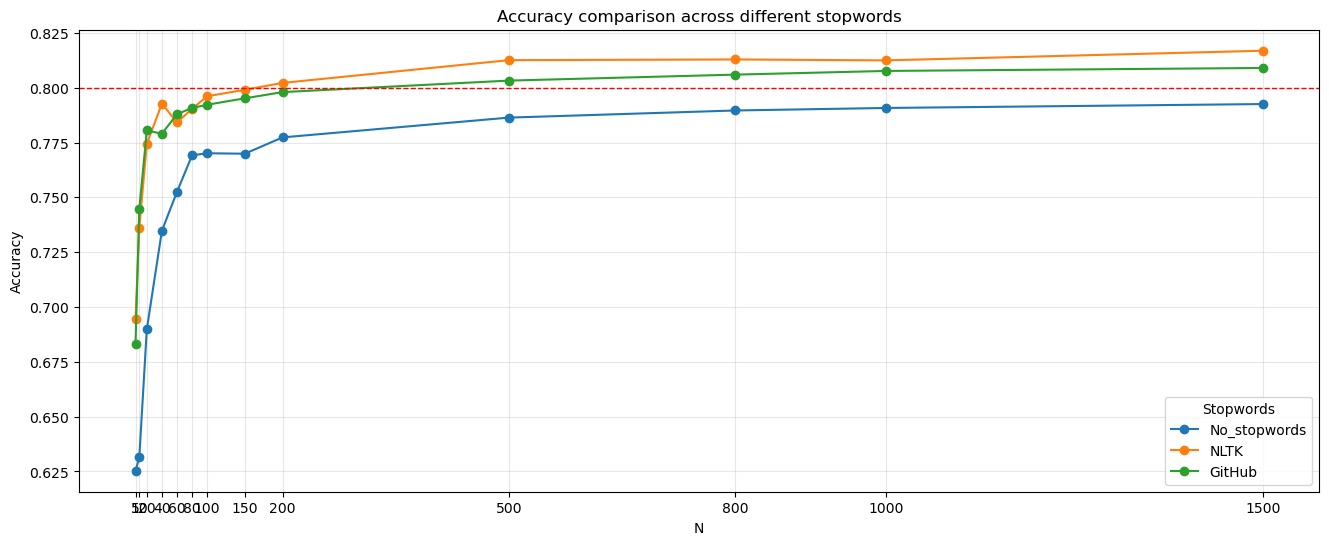

In [73]:
# Fem plot dels resultats per poder veure que està passant
accuracies_df.plot(figsize=(16, 6), marker='o')

# Dibuixem una línia horizontal a y = 0.80
plt.axhline(y=0.80, color='r', linestyle='--', linewidth=1)

plt.title('Accuracy comparison across different stopwords')
plt.xlabel('N')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend(title='Stopwords')
plt.xticks(accuracies_df.index)
plt.show()

## Conclusions

El fet que el percentatge de precisió entre l'execució amb la llista de $1298$ **stopwords** (`GitHub`) i la de $179$ (`NLTK`) sigui tan semblant ens indica que el que realment importa no és només la quantitat de **stopwords**, sinó la rellevància d’aquestes paraules dins del context. Per això, personalment creiem que és molt més interessant utilitzar `NLTK` ja que implica una llista molt més petita per un rendiment molt similar i, a vegades, més alt.

### Com afecta $N$ i les stopwords al model?

Quan augmentem $N$, el comportament del model millora de manera significativa fins a estabilitzar-se. Això es deu al fet que valors baixos de $N$ només tenen en compte les paraules més freqüents, cosa que pot introduir biaixos si aquestes paraules no són representatives. En canvi, amb valors molt alts de $N$, el model té accés a un conjunt molt ampli de paraules i l'efecte de les **stopwords** es dilueix perquè l'algorisme ja és capaç de gestionar termes irrellevants.

De forma molt similar, com més **stopwords** tinguem, millor funciona l’algorisme fins a arribar a un punt d’estabilització. Això es veu clarament amb les llistes de `GitHub` i `NLTK`: la diferència inicial és notable respecte a no utilitzar **stopwords**, però amb $N$ grans, l’impacte de tenir una llista més àmplia es fa molt menys significatiu.

### Elecció òptima de $N$ i stopwords

Seguint aquesta lògica, la millor elecció és utilitzar el valor de $N$ més alt possible i una llista de **stopwords** tan àmplia com sigui viable. Això garanteix que el model elimini les paraules més irrellevants sense perdre informació important. No obstant això, hem observat que l'efecte de "sempre escollir el més gran" és asimptòtic: arriba un punt on afegir més **stopwords** o augmentar més $N$ només aporta millores marginals que potser no compensen l'esforç.

Per tant, si ens haguessin de preguntar, triaríem un valor de $N=150$ juntament amb la llista de **stopwords** obtinguts de `NLTK`. Aquesta combinació proporciona una precisió superior al $80%$ sense la necessitat de continuar ampliant llistes o incrementant $N$ de manera innecessària.

### Reflexió final

El treball realitzat amb diferents valors de $N$ i diferents llistes de **stopwords** evidencia que un bon preprocessament, com una selecció adequada de paraules buides, pot tenir un impacte significatiu en la precisió d’un model. Però també hem vist que l’efecte d’aquestes decisions no és lineal: hi ha moments on els canvis són molt pronunciats (com en la diferència entre no utilitzar **stopwords**), i altres on les millores són mínimes. Això reforça la idea que la clau està en l'equilibri entre generalització i especificitat per al nostre cas concret.

#### Cas N=40

Pel cas $N=40$ podem veure que el màxim rendiment l'obtenim per la llista de ``NLTK``. Però ens sembla més interessant comentar la diferencia entre les diferents *accuracies*. Entre no utilitzar **stopwords** o utilizar la llista de ``NLTK`` tenim una diferencia del $5,23\%$ mentre que entre utilitzar ``NLTK`` o ``GitHub`` tan sols un $1,23\%$. Això, com ja hem comentat abans, és causat perque per $N$ petites l'efecte de les **stopwords** és molt gran ja que és probable que el model estigui molt esbiaixat.